# RMP 스텔러레이터 공명 분석

이 notebook은 해석적 스텔러레이터 공명 기하를 위한 주 공개 workflow입니다. 예전에 텍스트만 있던 두 tutorial을 하나의 시각적 계산으로 합쳤습니다.

1. 해석적 스텔러레이터 평형을 만들고 Poincaré section을 추적한다.
2. 공명 RMP Fourier component와 해석적 X/O fixed point를 계산한다.
3. 원시 section point를 geometry로 승격한다: crossing, fixed-point marker, 공명 surface, O-point 자기섬 폭 bar, local stable branch, coordinate overlay.
4. PEST-style grid와 함께 unperturbed section과 perturbed section을 비교한다.
5. 자기섬 폭, Chirikov overlap, $(m,n)$ 스펙트럼을 요약한다.
6. `pyna.plot` helper로 현대적인 multi-section figure를 만든다.

이 notebook은 문서 게시 전에 로컬에서 실행하도록 설계되어 있습니다. GitHub Pages는 자기력선 trace를 다시 계산하지 않고 저장된 출력을 렌더링합니다.

## [SETUP] Import와 publication style

In [1]:
import sys
import json
import pathlib
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

PROJECT_ROOT = None
for candidate in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
    if (candidate / 'pyna').is_dir() and (candidate / 'pyproject.toml').exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is not None and str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%matplotlib inline
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('png')

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 10,
    'figure.dpi': 150,
    'text.usetex': False,
    'axes.linewidth': 0.75,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

from pyna.toroidal.equilibrium.stellarator import simple_stellarator
from pyna.toroidal.visual.RMP_spectrum import (
    find_resonant_components_analytic,
    radial_rmp_field_template,
    compose_magnetic_perturbations,
    circular_shell_divergence_diagnostic,
    fieldline_velocity_spectrum_on_circular_surface,
    rmp_nrmp_mode_rows,
    sample_stellarator_cylindrical_field,
    compare_cyna_fixed_points_for_component,
    deformed_circular_section_rz,
    deformed_surface_map_residual,
    project_fixed_points_to_deformed_surface,
    CoupledFixedPointSweep,
    plot_perturbation_order_summary,
    scan_nonresonant_residual_order,
    scan_coupled_fixed_point_sweep,
    scan_rmp_amplitude_order,
    scan_rmp_phase_order,
    scan_rmp_resolution_convergence,
    compute_mn_spectrum,
    plot_mn_heatmap,
    ISLAND_CMAPS,
)
from pyna.toroidal.perturbation_spectrum import (
    analyze_resonant_island_chains_multi_n,
    nardon_radial_perturbation,
    radial_perturbation_Fourier_spectrum,
)
from pyna.toroidal.visual.magnetic_spectrum import (
    PoincareRationalTrace,
    plot_radial_mode_heatmap,
    plot_rational_surface_map,
    plot_spectrum_bar3d,
    plot_spectrum_heatmap,
)
from pyna.topo.poincare import poincare_from_fieldlines, ToroidalSection
from pyna.plot import (
    draw_pest_grid,
    draw_poincare_points,
    draw_rmp_resonance_section,
    plot_rmp_resonance_sections,
)

print('Setup complete. numpy', np.__version__, '  matplotlib', matplotlib.__version__)


Setup complete. numpy 2.4.6   matplotlib 3.11.0


## [EQ] Stellarator equilibrium 구성

다음 성질을 갖는 해석적 single-helicity 스텔러레이터를 사용합니다.
- Major radius $R_0=3.0$ m, minor radius $r_0=0.3$ m, on-axis field $B_0=2.5$ T
- Linear $q$ 프로파일: $q_0=1.5$ (axis) → $q_1=4.5$ (LCFS)
- Helical ripple: $(m_h,n_h)=(3,3)$, $\epsilon_h=0.03$

Safety factor 프로파일 $q(\psi)=q_0+(q_1-q_0)\psi$는 $[1.5,4.5]$ 범위를 덮으므로 $q=2/1,3/1,4/1$ 등 여러 공명이 plasma 안에 있습니다.

In [2]:
eq = simple_stellarator(
    R0=3.0, r0=0.3, B0=2.5,
    q0=1.5, q1=4.5,
    m_h=3, n_h=3, epsilon_h=0.03,
)
print(eq)
print(f'q range: [{eq.q0}, {eq.q1}]')
print(f'Resonant surface for (2,1): psi_res = {eq.resonant_psi(2,1)}')
print(f'Resonant surface for (4,2): psi_res = {eq.resonant_psi(4,2)}')
print(f'Resonant surface for (6,3): psi_res = {eq.resonant_psi(6,3)}')

# Convenience references
R0_eq = eq.R0
r0_eq = eq.r0


StellaratorSimple(R0=3.0 m, r0=0.3 m, B0=2.5 T, q=[1.5, 4.5], m_h=3, n_h=3, ε_h=0.03)
q range: [1.5, 4.5]
Resonant surface for (2,1): psi_res = [0.16666666666666666]
Resonant surface for (4,2): psi_res = [0.16666666666666666]
Resonant surface for (6,3): psi_res = [0.16666666666666666]


## [RMP_NRMP_WORKFLOW] RMP/nRMP decomposition

Flux surface 위의 perturbation mode는 local 자기력선 회전과 비교한 뒤에야 의미가 분명해집니다. Fourier 부호 규약을

$$F(\theta,\varphi)=\sum_{m,n} F_{mn}\exp[i(m\theta+n\varphi)],$$

으로 두면 local detuning은

$$\Delta_{mn}=m\iota+n, \qquad \iota=1/q.$$

입니다.

| 항목 | 조건 | 기하학적 효과 | pyna workflow |
| --- | --- | --- | --- |
| RMP | `abs(m*iota+n) <= tol` | 자기섬 chain을 열며, X/O point, O-point 폭 bar, separatrix branch가 의미 있는 first-order object가 된다 | `find_resonant_components_analytic`, `compare_cyna_fixed_points_for_component`, `draw_rmp_resonance_section` |
| nRMP | 모든 비공명 mode에 대해 `abs(m*iota+n) > tol` | 모든 비공명 mode가 smooth flux-surface deformation과 자기력선 속도 변조에 더해진다 | `fieldline_velocity_spectrum_on_circular_surface`, `FieldlineVelocitySpectrum.nonresonant_response()` |
| mixed 스펙트럼 | 둘 다 존재 | 공명 자기섬 geometry가 전체 nRMP-deformed surface 위에 놓인다 | `compose_magnetic_perturbations`, `nonresonant_response`, diagnostic용 `rmp_nrmp_mode_rows` |
| validation | vector field가 물리적이어야 함 | non-solenoidal template는 가짜 위상을 만들 수 있다 | `radial_rmp_field_template`, `circular_shell_divergence_diagnostic` |

핵심 차이는 RMP diagnostic은 공명 row에 집중하지만, nRMP response는 모든 비공명 row의 전체 합이라는 점입니다.

$$\delta r(\theta,\varphi)=\sum_{m\iota+n\ne0}\frac{F_{r,mn}}{i(m\iota+n)}\exp[i(m\theta+n\varphi)].$$

Contribution table은 ranking과 convergence 진단에 유용하지만, 모델 자체는 선택한 top component가 아니라 전체 비공명 스펙트럼입니다.

## [POINCARE_UNPERTURBED] φ=0에서 unperturbed Poincaré section

Unperturbed equilibrium의 자기력선을 추적하고 $\varphi=0$ plane에서 crossing을 기록합니다. 결과는 원시 sampled geometry입니다. 유용하지만 아직 topological object는 아닙니다. 뒤의 cell에서 공명 surface, X/O marker, local stable branch, PEST-style coordinate grid를 overlay하여 promotion layer를 추가합니다.

Crossing은 `pyna_output/poincare_unperturbed.json`에 cache됩니다.

Loaded from cache: 735 crossings


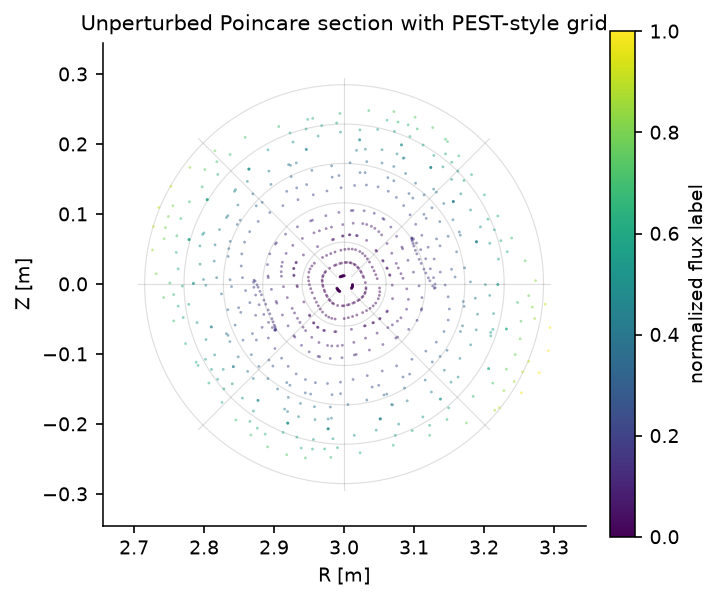

In [3]:
CACHE_UNPERT = pathlib.Path('pyna_output/poincare_unperturbed.json')
CACHE_UNPERT.parent.mkdir(exist_ok=True)

if CACHE_UNPERT.exists():
    _d = json.loads(CACHE_UNPERT.read_text())
    R_cross_u = np.array(_d['R'])
    Z_cross_u = np.array(_d['Z'])
    print(f'Loaded from cache: {len(R_cross_u)} crossings')
else:
    n_fieldlines = 15
    n_turns = 50
    dt = 0.08
    t_max = n_turns * 2 * np.pi * eq.R0

    R_starts = np.linspace(eq.R0 + 0.04*eq.r0, eq.R0 + 0.92*eq.r0, n_fieldlines)
    start_pts = np.zeros((n_fieldlines, 3))
    start_pts[:, 0] = R_starts
    start_pts[:, 2] = 0.0

    sections_u = [ToroidalSection(phi0=0.0)]
    print(f'Tracing {n_fieldlines} field lines x {n_turns} turns (dt={dt}, t_max={t_max:.1f} m)...')

    pmap_u = poincare_from_fieldlines(
        eq.field_func,
        start_pts,
        sections_u,
        t_max=t_max,
        dt=dt,
    )
    arr_u = pmap_u.crossing_array(0)
    R_cross_u = arr_u[:, 0]
    Z_cross_u = arr_u[:, 1]
    print(f'Computed: {len(R_cross_u)} crossings. Caching...')
    CACHE_UNPERT.write_text(json.dumps({'R': R_cross_u.tolist(), 'Z': Z_cross_u.tolist()}))
    print('Cached.')

fig_u, ax_u = plt.subplots(figsize=(4.7, 4.3), constrained_layout=True)
draw_pest_grid(ax_u, eq, alpha=0.22)
psi_pts = np.clip(((R_cross_u - eq.R0)**2 + Z_cross_u**2) / eq.r0**2, 0, 1)
draw_poincare_points(
    ax_u,
    R_cross_u,
    Z_cross_u,
    values=psi_pts,
    cmap='viridis',
    point_size=1.8,
    alpha=0.50,
    rasterized=False,
)
sm_u = plt.cm.ScalarMappable(cmap='viridis', norm=Normalize(0, 1))
fig_u.colorbar(sm_u, ax=ax_u, label='normalized flux label', shrink=0.82)
lim = 1.15 * eq.r0
ax_u.set_xlim(eq.R0 - lim, eq.R0 + lim)
ax_u.set_ylim(-lim, lim)
ax_u.set_aspect('equal')
ax_u.set_xlabel('R [m]')
ax_u.set_ylabel('Z [m]')
ax_u.set_title('Unperturbed Poincare section with PEST-style grid')
plt.show()


## [RMP_FIELD] RMP perturbation field 정의와 시각화

Base mode $(m,n)=(2,1)$, amplitude $\delta B=1$ mT인 single-mode RMP를 적용합니다. 사용자에게 보이는 template는

$$B_r=B_\mathrm{rmp}\cos(m\theta-n\varphi+\alpha),$$

입니다. 하지만 `radial_rmp_field_template`는 local circular-shell metric에서 전체 cylindrical vector field가 divergence-free가 되도록 필요한 compensating poloidal/toroidal component도 함께 추가합니다. 그림에 표시되는 radial projection은 여전히 익숙한 공명 구동 $\delta B^r$입니다.

같은 helper는 중요한 `m=1` branch도 지원합니다. 이 경우 radial divergence에 theta-independent part가 포함되므로 toroidal component가 필요합니다.

q=2/1 resonant surface: psi=0.167, r=12.2 cm
delta_B/B0 = 0.040%


Divergence diagnostics for the full vector perturbation:
mode        max |div|    rms |div|      rel max
m=2         6.642e-06    3.148e-06    5.300e-04
m=1         1.804e-06    7.949e-07    9.946e-05


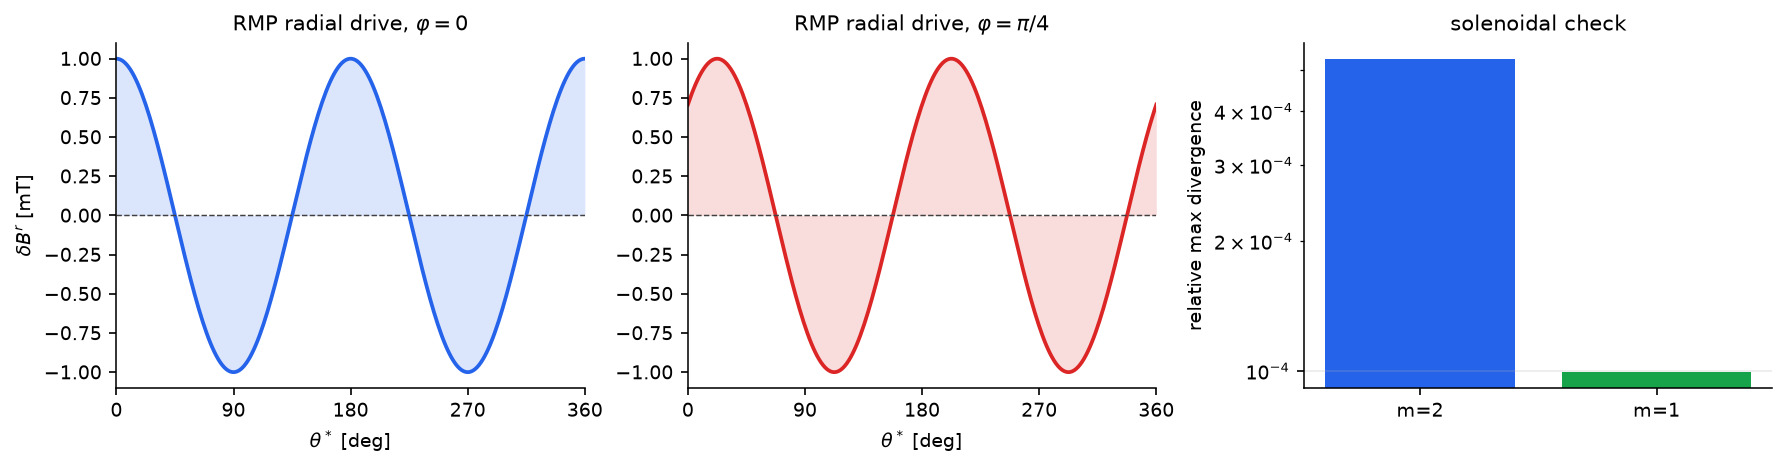

Divergence-free RMP field defined and visualised.


In [4]:
base_m, base_n = 2, 1
B_rmp = 1e-3  # 1 mT

delta_B_RMP = radial_rmp_field_template(
    base_m,
    base_n,
    amplitude=B_rmp,
    phase=0.0,
    axis_R=eq.R0,
)

psi_res_21 = eq.resonant_psi(2, 1)[0]
r_res_21 = np.sqrt(psi_res_21) * eq.r0
print(f'q=2/1 resonant surface: psi={psi_res_21:.3f}, r={r_res_21*100:.1f} cm')
print(f'delta_B/B0 = {B_rmp/eq.B0*100:.3f}%')

r_check = np.linspace(0.08, 0.28, 7)
div_m2 = circular_shell_divergence_diagnostic(
    delta_B_RMP,
    axis_R=eq.R0,
    r_values=r_check,
    n_theta=192,
    n_phi=192,
)
delta_B_m1_demo = radial_rmp_field_template(
    1,
    1,
    amplitude=B_rmp,
    phase=0.35,
    axis_R=eq.R0,
)
div_m1 = circular_shell_divergence_diagnostic(
    delta_B_m1_demo,
    axis_R=eq.R0,
    r_values=r_check,
    n_theta=192,
    n_phi=192,
)

print('Divergence diagnostics for the full vector perturbation:')
print('{:<8} {:>12} {:>12} {:>12}'.format('mode', 'max |div|', 'rms |div|', 'rel max'))
for label, diag in [('m=2', div_m2), ('m=1', div_m1)]:
    print(f'{label:<8} {diag.max_abs:12.3e} {diag.rms:12.3e} {diag.relative_max:12.3e}')

theta_arr = np.linspace(0, 2*np.pi, 240)
R_res = eq.R0 + r_res_21 * np.cos(theta_arr)
Z_res = r_res_21 * np.sin(theta_arr)

fig_rmp, axes_rmp = plt.subplots(1, 3, figsize=(11.8, 3.0), constrained_layout=True)
for ax, phi_val, phi_label, color in [
    (axes_rmp[0], 0.0, r'$\varphi=0$', '#2563eb'),
    (axes_rmp[1], np.pi/4, r'$\varphi=\pi/4$', '#dc2626'),
]:
    BR, BZ, _ = delta_B_RMP(R_res, Z_res, phi_val)
    dBpsi = BR*np.cos(theta_arr) + BZ*np.sin(theta_arr)
    ax.plot(np.degrees(theta_arr), dBpsi * 1e3, color=color, linewidth=1.8)
    ax.fill_between(np.degrees(theta_arr), 0, dBpsi * 1e3, color=color, alpha=0.16, linewidth=0)
    ax.axhline(0, color='0.25', lw=0.7, linestyle='--')
    ax.set_xlabel(r'$\theta^*$ [deg]')
    ax.set_title(f'RMP radial drive, {phi_label}')
    ax.set_xlim(0, 360)
    ax.set_xticks([0, 90, 180, 270, 360])
axes_rmp[0].set_ylabel(r'$\delta B^r$ [mT]')

axes_rmp[2].bar(['m=2', 'm=1'], [div_m2.relative_max, div_m1.relative_max], color=['#2563eb', '#16a34a'])
axes_rmp[2].set_yscale('log')
axes_rmp[2].set_ylabel('relative max divergence')
axes_rmp[2].set_title('solenoidal check')
axes_rmp[2].grid(True, axis='y', alpha=0.25)
plt.show()
print('Divergence-free RMP field defined and visualised.')

## [M1_RMP] m=1 phase-control mini-case

`m=1` perturbation은 흔하므로 edge case처럼 다루면 안 됩니다. 여기서는 같은 divergence-free template로 단순한 `q=1` equilibrium에서 `(1,1)` 공명을 구동합니다. 한 짧은 계산에서 세 가지를 확인합니다: field가 수치적으로 solenoidal인지, 추출한 `b_{1,-1}` phase가 template phase를 따르는지, 예측한 O/X point가 radial drive의 zero crossing 위에 놓이는지.

  k=1: (1,1) ψ_res=0.500 q_res=1.000 |b_mn|=5.000e-04 phase_arg=24.6° w_ψ=0.1265 (2.68 cm) θ_O=245.4° θ_X=65.4°
m=1 resonant surface: psi=0.500, r=21.2 cm
arg b_(1,-1) = 0.430000 rad, template phase = 0.430000 rad
|b_(1,-1)| = 5.000e-04 T, expected about B_rmp/2 = 5.000e-04 T
m=1 divergence relative max = 9.946e-05
O-point theta = 245.36 deg
X-point theta = 65.36 deg


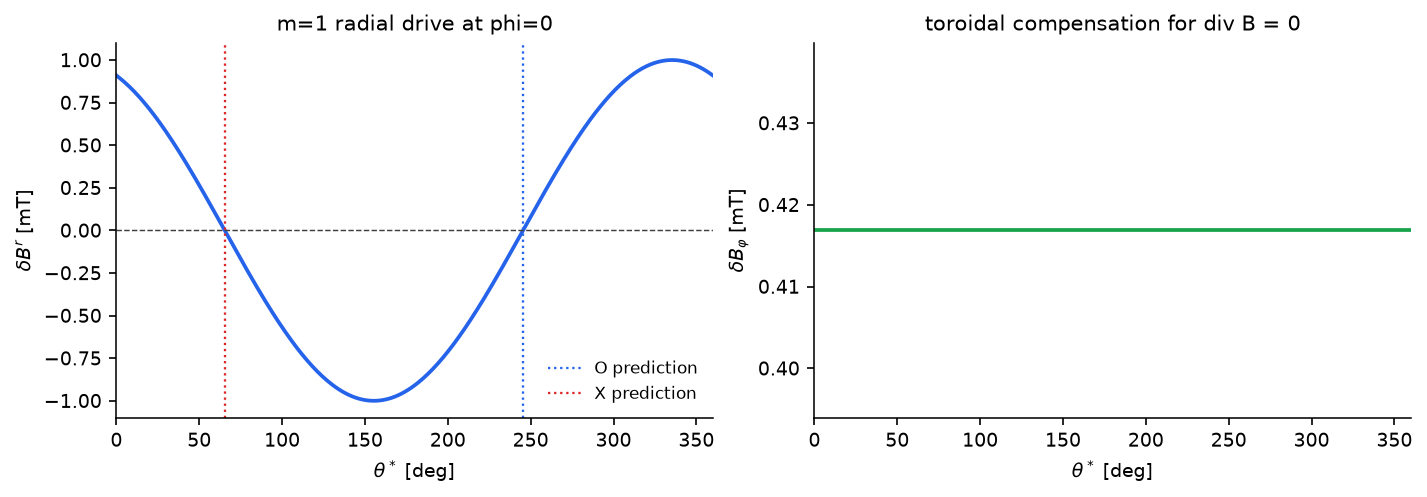

In [5]:

eq_m1 = simple_stellarator(
    R0=eq.R0,
    r0=eq.r0,
    B0=eq.B0,
    q0=0.75,
    q1=1.25,
    m_h=eq.m_h,
    n_h=eq.n_h,
    epsilon_h=0.0,
)
m1_phase = 0.43
delta_B_m1 = radial_rmp_field_template(
    1,
    1,
    amplitude=B_rmp,
    phase=m1_phase,
    axis_R=eq_m1.R0,
)
psi_res_m1 = eq_m1.resonant_psi(1, 1)[0]
r_res_m1 = np.sqrt(psi_res_m1) * eq_m1.r0
m1_diag = circular_shell_divergence_diagnostic(
    delta_B_m1,
    axis_R=eq_m1.R0,
    r_values=np.linspace(0.08, 0.28, 7),
    n_theta=192,
    n_phi=192,
)
component_m1 = find_resonant_components_analytic(
    eq_m1,
    delta_B_m1,
    base_m=1,
    base_n=1,
    max_harmonic=1,
    n_theta=128,
    n_phi=64,
    min_amplitude=1e-16,
)[0]

print(f'm=1 resonant surface: psi={psi_res_m1:.3f}, r={r_res_m1*100:.1f} cm')
print(f'arg b_(1,-1) = {np.angle(component_m1.b_mn):.6f} rad, template phase = {m1_phase:.6f} rad')
print(f'|b_(1,-1)| = {abs(component_m1.b_mn):.3e} T, expected about B_rmp/2 = {0.5*B_rmp:.3e} T')
print(f'm=1 divergence relative max = {m1_diag.relative_max:.3e}')
print(f'O-point theta = {np.degrees(component_m1.opoint_theta):.2f} deg')
print(f'X-point theta = {np.degrees(component_m1.xpoint_theta):.2f} deg')

theta_m1 = np.linspace(0, 2*np.pi, 361)
R_m1 = eq_m1.R0 + r_res_m1*np.cos(theta_m1)
Z_m1 = r_res_m1*np.sin(theta_m1)
BR_m1, BZ_m1, Bphi_m1 = delta_B_m1(R_m1, Z_m1, 0.0)
dBr_m1 = BR_m1*np.cos(theta_m1) + BZ_m1*np.sin(theta_m1)

fig_m1, (ax_m1, ax_m1b) = plt.subplots(1, 2, figsize=(9.4, 3.2), constrained_layout=True)
ax_m1.plot(np.degrees(theta_m1), dBr_m1*1e3, color='#2563eb', lw=1.8)
ax_m1.axhline(0, color='0.25', lw=0.7, ls='--')
ax_m1.axvline(np.degrees(component_m1.opoint_theta), color='#2563eb', lw=1.1, ls=':', label='O prediction')
ax_m1.axvline(np.degrees(component_m1.xpoint_theta), color='#dc2626', lw=1.1, ls=':', label='X prediction')
ax_m1.set_xlim(0, 360)
ax_m1.set_xlabel(r'$\theta^*$ [deg]')
ax_m1.set_ylabel(r'$\delta B^r$ [mT]')
ax_m1.set_title('m=1 radial drive at phi=0')
ax_m1.legend(frameon=False, fontsize=8)

ax_m1b.plot(np.degrees(theta_m1), Bphi_m1*1e3, color='#16a34a', lw=1.8)
ax_m1b.set_xlim(0, 360)
ax_m1b.set_xlabel(r'$\theta^*$ [deg]')
ax_m1b.set_ylabel(r'$\delta B_\varphi$ [mT]')
ax_m1b.set_title('toroidal compensation for div B = 0')
plt.show()


## [RESONANT_COMPONENTS] 공명 Fourier component 찾기

각 공명 flux surface에서 RMP field를 2D FFT로 분해하고, 공명 $(m_k,n_k)=k\times(2,1)$ harmonic의 amplitude를 추출합니다. **자기섬 half-width**는 Rutherford formula로 주어집니다.

$$w_\psi=4\sqrt{\frac{|b_{mn}|}{m|\partial q/\partial\psi|}}$$

결과는 `pyna_output/rmp_components.json`에 cache됩니다.

In [6]:
CACHE_COMP = pathlib.Path('pyna_output/rmp_components.json')
CACHE_COMP.parent.mkdir(exist_ok=True)

print('Computing resonant components (n_theta=32, n_phi=16)...')
components = find_resonant_components_analytic(
    eq, delta_B_RMP, base_m=base_m, base_n=base_n,
    max_harmonic=3, n_theta=32, n_phi=16,
)
print(f'Found {len(components)} resonant components.')

# Cache as JSON
_comp_data = [{
    'm': c.m, 'n': c.n, 'harmonic_order': c.harmonic_order,
    'b_mn_real': float(c.b_mn.real), 'b_mn_imag': float(c.b_mn.imag),
    'psi_res': float(c.psi_res), 'q_res': float(c.q_res),
    'half_width_psi': float(c.half_width_psi),
    'half_width_r': float(c.half_width_r),
    'opoint_theta': float(c.opoint_theta),
    'xpoint_theta': float(c.xpoint_theta),
    'q_prime_sign': int(c.q_prime_sign),
} for c in components]
CACHE_COMP.write_text(json.dumps(_comp_data, indent=2))
print('Cached to', CACHE_COMP)

# Print table
print()
print(f'{"k":>3}  {"(m,n)":>8}  {"psi_res":>8}  {"q_res":>6}  {"b_mn|":>10}  {"w_psi":>8}  {"w_r (cm)":>10}  {"theta_O":>8}  {"theta_X":>8}')
print('-'*80)
for c in components:
    print(f'{c.harmonic_order:>3}  ({c.m},{c.n}){"":>4}  {c.psi_res:>8.4f}  {c.q_res:>6.3f}  {abs(c.b_mn):>10.3e}  {c.half_width_psi:>8.4f}  {c.half_width_r*100:>10.2f}  {np.degrees(c.opoint_theta):>8.1f}  {np.degrees(c.xpoint_theta):>8.1f}')


Computing resonant components (n_theta=32, n_phi=16)...
  k=1: (2,1) ψ_res=0.167 q_res=2.000 |b_mn|=5.000e-04 phase_arg=-0.0° w_ψ=0.0365 (1.34 cm) θ_O=135.0° θ_X=45.0°
  k=2: (4,2) — |b_mn|=4.57e-21 below threshold
  k=3: (6,3) — |b_mn|=1.98e-20 below threshold
Found 1 resonant components.
Cached to pyna_output/rmp_components.json

  k     (m,n)   psi_res   q_res       b_mn|     w_psi    w_r (cm)   theta_O   theta_X
--------------------------------------------------------------------------------
  1  (2,1)        0.1667   2.000   5.000e-04    0.0365        1.34     135.0      45.0


## [POINCARE_PERTURBED] Geometry promotion: crossings -> X/O points -> manifolds

Perturbed trace는 sampled Poincaré point를 제공합니다. 해석적 RMP 스펙트럼은 fixed-point와 자기섬 폭 prediction을 제공합니다. `pyna.plot.draw_rmp_resonance_section`은 이 둘을 하나의 section geometry로 결합합니다.

- Flux label로 색칠한 Poincaré point
- PEST-style $(S,\theta^*)$ grid line
- 각 harmonic의 공명 surface
- 해석적 fixed-point formula에서 얻은 O-point와 X-point
- 공명 Fourier amplitude로 길이가 정해지는 O-point radial bar
- X-point에서 생기는 local stable separatrix branch

이는 general geometry workflow와 같은 promotion idea입니다. 원시 sample은 명시적인 model 또는 diagnostic이 승격을 정당화하기 전까지 persistent geometric object 및 overlay와 구분해 둡니다.

Loaded perturbed Poincare from cache (6 sections).
phi=0 section: 735 crossings


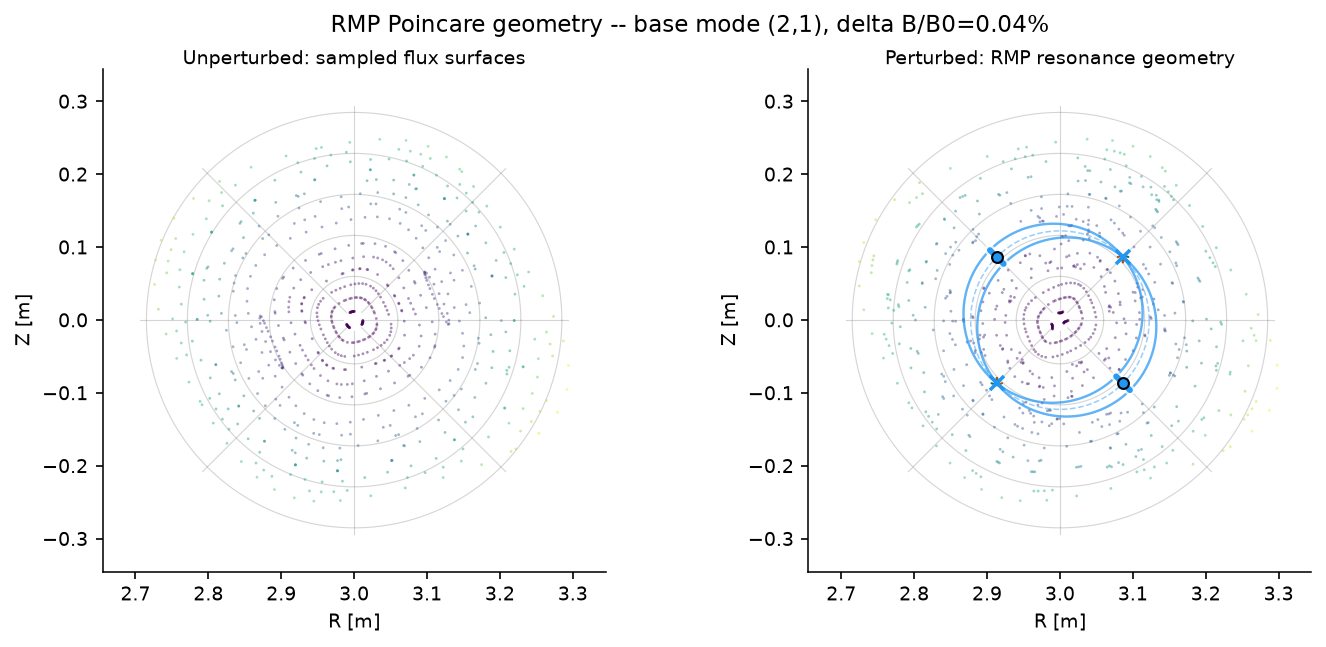

In [7]:
# Perturbed field_func
# --------------------
def field_func_perturbed(rzphi_1d):
    """Unit-tangent dRZphi/ds for the field-line ODE with RMP added."""
    rzphi_1d = np.asarray(rzphi_1d, dtype=float)
    R, Z, phi = rzphi_1d[0], rzphi_1d[1], rzphi_1d[2]
    theta = np.arctan2(Z, R - R0_eq)
    psi = eq.psi_ax(R, Z)
    q = float(eq.q_of_psi(psi))
    r_minor = np.sqrt((R - R0_eq)**2 + Z**2)
    B_phi = eq.B0 * eq.R0 / R
    B_pol = B_phi * r_minor / (R * max(abs(q), 1e-3))
    if r_minor > 1e-10:
        BR0 = -B_pol * np.sin(theta)
        BZ0 =  B_pol * np.cos(theta)
    else:
        BR0 = BZ0 = 0.0
    delta_BR_eq = eq.epsilon_h * eq.B0 * psi * np.cos(eq.m_h * theta - eq.n_h * phi)
    db = delta_B_RMP(R, Z, phi)
    BR_tot = BR0 + delta_BR_eq + db[0]
    BZ_tot = BZ0 + db[1]
    B_phi_tot = B_phi + db[2]
    B_mag = np.sqrt(BR_tot**2 + BZ_tot**2 + B_phi_tot**2) + 1e-30
    return np.array([BR_tot/B_mag, BZ_tot/B_mag, B_phi_tot/(R*B_mag)])

CACHE_PERT = pathlib.Path('pyna_output/poincare_perturbed_divfree.json')
CACHE_PERT.parent.mkdir(exist_ok=True)

phi_sections_deg = [0, 60, 120, 180, 240, 300]
phi_sections = np.array(phi_sections_deg) * np.pi / 180.0

if CACHE_PERT.exists():
    _d = json.loads(CACHE_PERT.read_text())
    all_sections_data = _d['sections']
    print(f'Loaded perturbed Poincare from cache ({len(all_sections_data)} sections).')
else:
    sections_p = [ToroidalSection(phi0=ph) for ph in phi_sections]
    n_fieldlines, n_turns, dt = 15, 50, 0.08
    t_max = n_turns * 2 * np.pi * eq.R0
    start_pts = np.zeros((n_fieldlines, 3))
    start_pts[:, 0] = np.linspace(eq.R0 + 0.04*eq.r0, eq.R0 + 0.92*eq.r0, n_fieldlines)

    print(f'Tracing {n_fieldlines} field lines x {n_turns} turns (t_max={t_max:.1f} m)...')
    pmap_p = poincare_from_fieldlines(field_func_perturbed, start_pts, sections_p, t_max=t_max, dt=dt)
    all_sections_data = []
    for i_sec, phi_deg in enumerate(phi_sections_deg):
        arr = pmap_p.crossing_array(i_sec)
        print(f'  phi={phi_deg} deg: {len(arr)} crossings')
        all_sections_data.append({'R': arr[:, 0].tolist() if len(arr) else [], 'Z': arr[:, 1].tolist() if len(arr) else []})
    CACHE_PERT.write_text(json.dumps({'phi_sections_deg': phi_sections_deg, 'sections': all_sections_data}))
    print('Computed and cached.')

R_cross_p0 = np.array(all_sections_data[0]['R'])
Z_cross_p0 = np.array(all_sections_data[0]['Z'])
print(f'phi=0 section: {len(R_cross_p0)} crossings')

fig2, (axL, axR) = plt.subplots(1, 2, figsize=(9.4, 4.2), constrained_layout=True)

# The low-level plot layers are independently selectable by name.
draw_rmp_resonance_section(
    axL,
    R_cross_u,
    Z_cross_u,
    eq=eq,
    components=[],
    phi=0.0,
    title='Unperturbed: sampled flux surfaces',
    overlays=('pest_grid', 'poincare'),
    point_size=1.8,
    point_alpha=0.46,
)
draw_rmp_resonance_section(
    axR,
    R_cross_p0,
    Z_cross_p0,
    eq=eq,
    components=components,
    phi=0.0,
    colors=ISLAND_CMAPS,
    title='Perturbed: RMP resonance geometry',
    overlays=('pest_grid', 'poincare', 'resonant_surfaces', 'stable_branches', 'island_width_bars', 'xo'),
    point_size=1.8,
    point_alpha=0.46,
)

fig2.suptitle(
    f'RMP Poincare geometry -- base mode ({base_m},{base_n}), '
    f'delta B/B0={B_rmp/eq.B0*100:.2f}%',
    fontsize=11,
)
plt.show()


## [CYNA_FIXED_POINTS] Newton fixed point와 RMP 스펙트럼 phase 비교

RMP 스펙트럼은 first-order O/X-point phase를 예측합니다. 여기서는 accelerated `cyna` Newton map으로 그 seed를 true periodic-orbit fixed point로 refine한 뒤 phase error를 측정합니다. RMP-only case는 code sanity check이고, 해석적 helical ripple을 추가하면 first-order 스펙트럼이 의도적으로 무시하는 finite-amplitude/model shift가 나타납니다.

Building cyna field: RMP only


Building cyna field: RMP + analytic helical ripple



case                           kind branch    theta*   theta_N     dtheta    m*dtheta     dr [cm]    residual
-------------------------------------------------------------------------------------------------------------
RMP only                        O/O      0   315.000   314.940    -0.0602     -0.1203      0.2298     1.4e-14
RMP only                        O/O      1   135.000   135.059     0.0588      0.1176      0.2303     9.2e-15
RMP only                        X/X      0    45.000    44.940    -0.0600     -0.1200     -0.2520     4.7e-14
RMP only                        X/X      1   225.000   225.059     0.0588      0.1176     -0.2515     1.7e-14
  -> RMP only: max |dtheta|=0.0602 deg, max |m*dtheta|=0.1203 deg
RMP + analytic helical ripple   O/O      0   315.000   318.588     3.5877      7.1754      1.2050     5.0e-12
RMP + analytic helical ripple   O/O      1   135.000   138.420     3.4195      6.8391      1.1869     2.2e-15
RMP + analytic helical ripple   X/X      0    45.000 

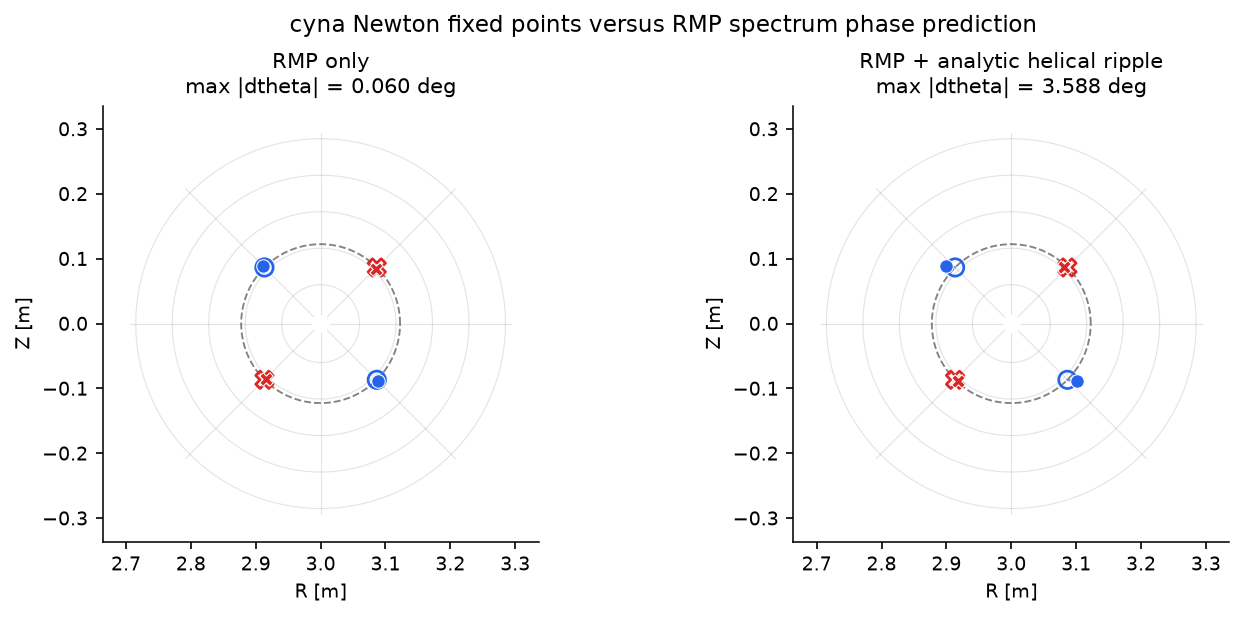

In [8]:
# Build a physical cylindrical field for cyna and compare Newton fixed points.
def row_newton_theta_deg(row, eq_case):
    axis_R, axis_Z = eq_case.magnetic_axis
    theta = np.arctan2(row.newton_Z - axis_Z, row.newton_R - axis_R) % (2*np.pi)
    return float(np.degrees(theta))


cyna_rows_by_case = {}
cyna_eq_by_case = {}
if components:
    eq_rmp_only = simple_stellarator(
        R0=eq.R0, r0=eq.r0, B0=eq.B0,
        q0=eq.q0, q1=eq.q1,
        m_h=eq.m_h, n_h=eq.n_h, epsilon_h=0.0,
    )
    try:
        for case_label, eq_case in [
            ('RMP only', eq_rmp_only),
            ('RMP + analytic helical ripple', eq),
        ]:
            print(f'Building cyna field: {case_label}')
            field_case = sample_stellarator_cylindrical_field(
                eq_case,
                delta_B_RMP,
                nR=128,
                nPhi=128,
                label=f'analytic_rmp_for_cyna_{case_label.replace(" ", "_").lower()}',
            )
            rows = compare_cyna_fixed_points_for_component(
                field_case,
                components[0],
                eq_case,
                DPhi=0.015,
                max_iter=80,
                tol=1e-11,
                n_threads=4,
            )
            cyna_rows_by_case[case_label] = rows
            cyna_eq_by_case[case_label] = eq_case
    except ImportError as exc:
        print('cyna fixed-point comparison skipped:', exc)

if cyna_rows_by_case:
    print()
    header = '{:<30} {:>4} {:>6} {:>9} {:>9} {:>10} {:>11} {:>11} {:>11}'.format(
        'case', 'kind', 'branch', 'theta*', 'theta_N', 'dtheta', 'm*dtheta', 'dr [cm]', 'residual'
    )
    print(header)
    print('-' * len(header))
    for case_label, rows in cyna_rows_by_case.items():
        eq_case = cyna_eq_by_case[case_label]
        for row in rows:
            theta_n = row_newton_theta_deg(row, eq_case)
            print('{:<30} {:>4} {:>6d} {:>9.3f} {:>9.3f} {:>10.4f} {:>11.4f} {:>11.4f} {:>11.1e}'.format(
                case_label,
                row.predicted_kind + '/' + (row.newton_kind or '?'),
                row.branch,
                row.predicted_theta_deg,
                theta_n,
                row.theta_error_deg,
                row.helical_phase_error_deg,
                row.radial_error_cm,
                row.residual,
            ))
        max_dtheta = max(abs(row.theta_error_deg) for row in rows)
        max_helical = max(abs(row.helical_phase_error_deg) for row in rows)
        print(f'  -> {case_label}: max |dtheta|={max_dtheta:.4f} deg, max |m*dtheta|={max_helical:.4f} deg')

if cyna_rows_by_case:
    fig_cmp, axes_cmp = plt.subplots(1, len(cyna_rows_by_case), figsize=(9.2, 4.0), constrained_layout=True)
    axes_cmp = np.atleast_1d(axes_cmp)
    for ax, (case_label, rows) in zip(axes_cmp, cyna_rows_by_case.items()):
        eq_case = cyna_eq_by_case[case_label]
        draw_pest_grid(ax, eq_case, alpha=0.18)
        r_res = np.sqrt(components[0].psi_res) * eq_case.r0
        theta_ring = np.linspace(0, 2*np.pi, 361)
        ax.plot(eq_case.R0 + r_res*np.cos(theta_ring), r_res*np.sin(theta_ring),
                color='0.25', lw=0.9, ls='--', alpha=0.65)
        for row in rows:
            color = '#2563eb' if row.predicted_kind == 'O' else '#dc2626'
            marker = 'o' if row.predicted_kind == 'O' else 'X'
            ax.plot([row.predicted_R, row.newton_R], [row.predicted_Z, row.newton_Z],
                    color=color, lw=1.0, alpha=0.65)
            ax.scatter(row.predicted_R, row.predicted_Z, marker=marker, s=70,
                       facecolors='none', edgecolors=color, linewidths=1.3, zorder=5)
            ax.scatter(row.newton_R, row.newton_Z, marker=marker, s=42,
                       color=color, edgecolors='white', linewidths=0.5, zorder=6)
        lim = 1.12 * eq_case.r0
        ax.set_xlim(eq_case.R0 - lim, eq_case.R0 + lim)
        ax.set_ylim(-lim, lim)
        ax.set_aspect('equal')
        ax.set_xlabel('R [m]')
        ax.set_ylabel('Z [m]')
        max_dtheta = max(abs(row.theta_error_deg) for row in rows)
        ax.set_title(f'{case_label}\nmax |dtheta| = {max_dtheta:.3f} deg')
    fig_cmp.suptitle('cyna Newton fixed points versus RMP spectrum phase prediction', fontsize=11)
    plt.show()

## [NONRESONANT_DEFORMATION] 비공명 ripple을 flux-surface deformation으로 보기

이 해석 평형의 helical ripple은 `(m,n)=(2,1)` 자기섬을 여는 공명 RMP component가 아닙니다. 그래도 가까운 flux surface의 geometry를 바꿉니다. Newton fixed point를 undeformed circular surface와 비교하면, 이 smooth displacement가 인위적인 phase error처럼 보입니다.

여기서는 helical-ripple contribution을 자기력선 ODE에서 sample합니다.
$$\frac{dr}{d\phi}=F_r(\theta,\phi), \qquad \frac{d\theta}{d\phi}=\iota+F_\theta(\theta,\phi),$$
`F_r`와 `F_theta`를 Fourier transform하고 모든 비공명 coefficient에 대한 homological equation을 풉니다. Response object는 total deformation과 contribution ranking을 모두 보관합니다. Ranking은 diagnostic이고, 아래에서 쓰는 deformation은 full summed nRMP response입니다.

nRMP total response uses 12 non-resonant modes and excludes 2 resonant modes.
Largest nRMP response contributors; these rank the sum but do not replace it:
   (m,n)     detuning |delta_r_mn| cm       cum frac
(-4, 3)    1.000e+00         0.3755          0.397
( 4,-3)   -1.000e+00         0.3755          0.794
(-2, 3)    2.000e+00         0.1877          0.893
( 2,-3)   -2.000e+00         0.1877          0.992
(-5, 3)    5.000e-01         0.0306          0.995
( 5,-3)   -5.000e-01         0.0306          0.997

Raw circular-surface max |dtheta|:       3.5877 deg
Deformed-surface-coordinate max |dtheta|: 1.4748 deg
Max Newton-to-deformed-section distance:  0.822 cm

kind branch   raw dtheta  deformed dtheta distance [cm]
-------------------------------------------------------
O         0       3.5877           0.6159         0.822
O         1       3.4195           0.7933         0.783
X         0       2.0428          -1.4748         0.250
X         1       1.9400          -1.1567      

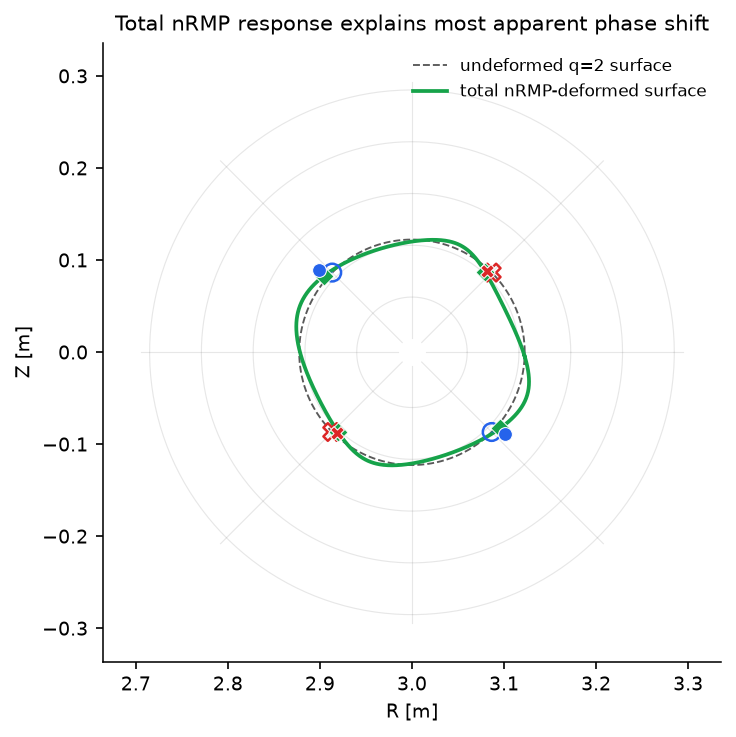

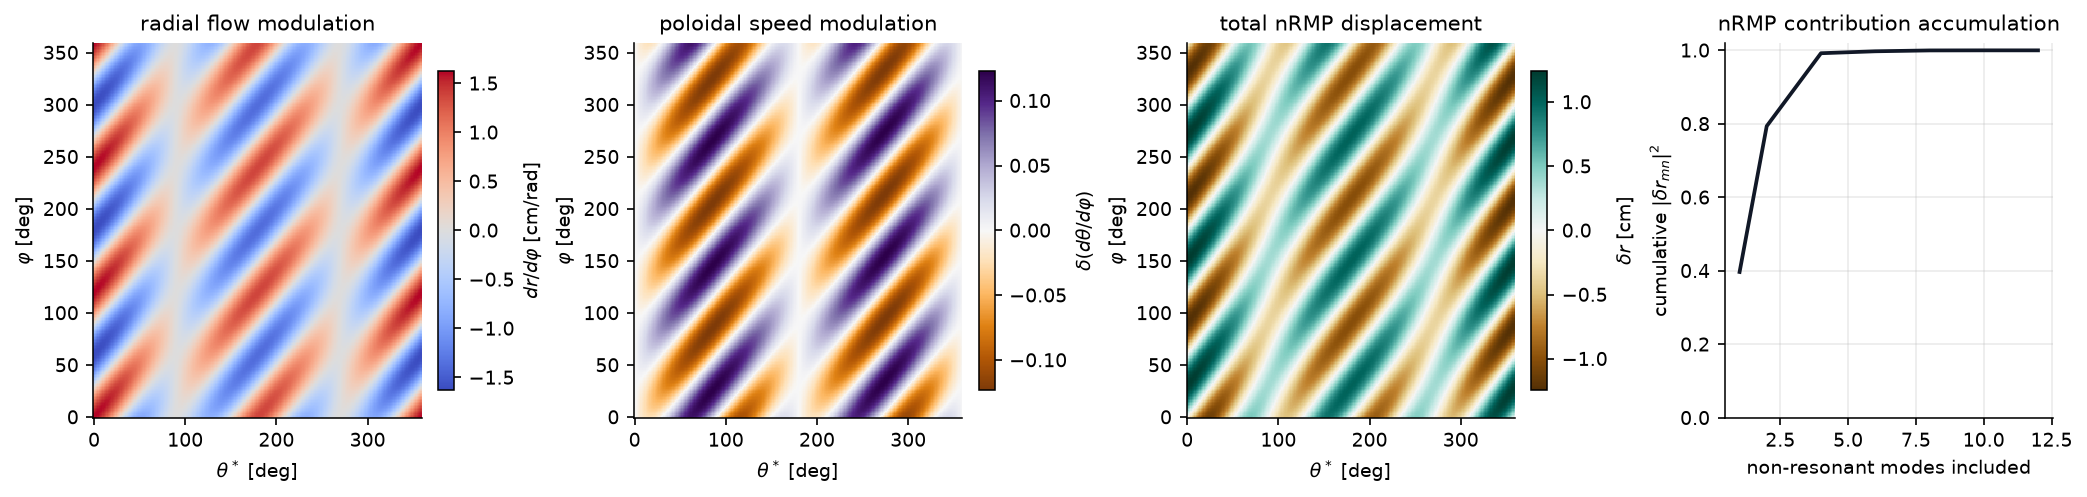

In [9]:
def helical_ripple_delta_B(eq_case):
    """Return the analytic helical-ripple contribution used by simple_stellarator."""
    def delta_B_helical(R, Z, phi):
        R_arr = np.asarray(R, dtype=float)
        Z_arr = np.asarray(Z, dtype=float)
        phi_arr = np.asarray(phi, dtype=float)
        theta = np.arctan2(Z_arr, R_arr - eq_case.R0)
        psi = eq_case.psi_ax(R_arr, Z_arr)
        dBR = eq_case.epsilon_h * eq_case.B0 * psi * np.cos(eq_case.m_h * theta - eq_case.n_h * phi_arr)
        return np.array([
            dBR,
            np.zeros_like(dBR, dtype=float),
            np.zeros_like(dBR, dtype=float),
        ])
    return delta_B_helical


def helical_velocity_response(eq_case, psi_res, n_theta=256, n_phi=256, include_shear=False):
    velocity = fieldline_velocity_spectrum_on_circular_surface(
        eq_case,
        helical_ripple_delta_B(eq_case),
        psi_res,
        n_theta=n_theta,
        n_phi=n_phi,
        m_max=8,
        n_max=8,
        min_amplitude=1e-12,
    )
    return velocity.nonresonant_response(include_shear=include_shear)


def helical_velocity_deformation(eq_case, psi_res, n_theta=256, n_phi=256, include_shear=False):
    response = helical_velocity_response(
        eq_case,
        psi_res,
        n_theta=n_theta,
        n_phi=n_phi,
        include_shear=include_shear,
    )
    return response.deformation, response.velocity.r_minor, response.velocity


case_label = 'RMP + analytic helical ripple'
if components and case_label in cyna_rows_by_case:
    rows = cyna_rows_by_case[case_label]
    eq_case = cyna_eq_by_case[case_label]
    response_helical = helical_velocity_response(eq_case, components[0].psi_res)
    deformation = response_helical.deformation
    velocity_helical = response_helical.velocity
    r_res = velocity_helical.r_minor
    projected_rows = project_fixed_points_to_deformed_surface(
        rows,
        eq_case,
        deformation,
        r_minor=r_res,
        theta_window=0.35,
    )

    print(
        'nRMP total response uses '
        f'{response_helical.n_nonresonant_modes} non-resonant modes '
        f'and excludes {response_helical.n_resonant_modes} resonant modes.'
    )
    print('Largest nRMP response contributors; these rank the sum but do not replace it:')
    print('{:>8} {:>12} {:>14} {:>14}'.format('(m,n)', 'detuning', '|delta_r_mn| cm', 'cum frac'))
    for contrib in response_helical.contribution_rows(top=6):
        print('({:>2d},{:>2d}) {:>12.3e} {:>14.4f} {:>14.3f}'.format(
            contrib.m,
            contrib.n,
            contrib.detuning,
            100.0 * contrib.radial_response_weight,
            contrib.cumulative_fraction,
        ))
    print()

    raw_max = max(abs(row.theta_error_deg) for row in rows)
    corrected_max = max(abs(row.theta_error_deg) for row in projected_rows)
    nearest_max = max(row.distance_cm for row in projected_rows)
    print(f'Raw circular-surface max |dtheta|:       {raw_max:.4f} deg')
    print(f'Deformed-surface-coordinate max |dtheta|: {corrected_max:.4f} deg')
    print(f'Max Newton-to-deformed-section distance:  {nearest_max:.3f} cm')
    print()
    header = '{:<4} {:>6} {:>12} {:>16} {:>13}'.format(
        'kind', 'branch', 'raw dtheta', 'deformed dtheta', 'distance [cm]'
    )
    print(header)
    print('-' * len(header))
    for row, proj in zip(rows, projected_rows):
        print('{:<4} {:>6d} {:>12.4f} {:>16.4f} {:>13.3f}'.format(
            row.predicted_kind,
            row.branch,
            row.theta_error_deg,
            proj.theta_error_deg,
            proj.distance_cm,
        ))

    theta_line = np.linspace(0.0, 2*np.pi, 721)
    R_circ = eq_case.R0 + r_res*np.cos(theta_line)
    Z_circ = r_res*np.sin(theta_line)
    R_def, Z_def = deformed_circular_section_rz(eq_case, r_res, deformation, theta_line)

    fig_def, ax_def = plt.subplots(figsize=(5.2, 4.8), constrained_layout=True)
    draw_pest_grid(ax_def, eq_case, alpha=0.16)
    ax_def.plot(R_circ, Z_circ, color='0.35', lw=0.9, ls='--', label='undeformed q=2 surface')
    ax_def.plot(R_def, Z_def, color='#16a34a', lw=1.8, label='total nRMP-deformed surface')

    for row, proj in zip(rows, projected_rows):
        color = '#2563eb' if row.predicted_kind == 'O' else '#dc2626'
        marker = 'o' if row.predicted_kind == 'O' else 'X'
        ax_def.plot([row.predicted_R, row.newton_R], [row.predicted_Z, row.newton_Z],
                    color=color, lw=0.8, alpha=0.35)
        ax_def.plot([proj.closest_R, row.newton_R], [proj.closest_Z, row.newton_Z],
                    color=color, lw=1.1, ls=':', alpha=0.9)
        ax_def.scatter(row.predicted_R, row.predicted_Z, marker=marker, s=72,
                       facecolors='none', edgecolors=color, linewidths=1.2, zorder=5)
        ax_def.scatter(proj.closest_R, proj.closest_Z, marker='D', s=42,
                       color='#16a34a', edgecolors='white', linewidths=0.45, zorder=6)
        ax_def.scatter(row.newton_R, row.newton_Z, marker=marker, s=44,
                       color=color, edgecolors='white', linewidths=0.5, zorder=7)

    lim = 1.12 * eq_case.r0
    ax_def.set_xlim(eq_case.R0 - lim, eq_case.R0 + lim)
    ax_def.set_ylim(-lim, lim)
    ax_def.set_aspect('equal')
    ax_def.set_xlabel('R [m]')
    ax_def.set_ylabel('Z [m]')
    ax_def.set_title('Total nRMP response explains most apparent phase shift')
    ax_def.legend(frameon=False, loc='upper right', fontsize=8)
    plt.show()

    TT_h, PP_h, dr_h, dtheta_h = response_helical.real_fields()
    counts_h, cumulative_h = response_helical.cumulative_contribution()
    theta_deg_h = np.degrees(velocity_helical.theta)
    phi_deg_h = np.degrees(velocity_helical.phi)
    fig_flow, axes_flow = plt.subplots(1, 4, figsize=(13.8, 3.2), constrained_layout=True)
    panels = [
        (velocity_helical.radial_velocity * 100.0, r'$dr/d\varphi$ [cm/rad]', 'radial flow modulation', 'coolwarm'),
        (velocity_helical.poloidal_velocity, r'$\delta(d\theta/d\varphi)$', 'poloidal speed modulation', 'PuOr'),
        (dr_h * 100.0, r'$\delta r$ [cm]', 'total nRMP displacement', 'BrBG'),
    ]
    for ax, (data, cbar_label, title, cmap) in zip(axes_flow[:3], panels):
        vmax = np.nanmax(np.abs(data))
        im = ax.pcolormesh(
            theta_deg_h,
            phi_deg_h,
            data,
            shading='auto',
            cmap=cmap,
            vmin=-vmax,
            vmax=vmax,
        )
        ax.set_xlabel(r'$\theta^*$ [deg]')
        ax.set_ylabel(r'$\varphi$ [deg]')
        ax.set_title(title)
        fig_flow.colorbar(im, ax=ax, label=cbar_label, shrink=0.85)
    axes_flow[3].plot(counts_h, cumulative_h, color='#111827', lw=1.8)
    axes_flow[3].set_ylim(0, 1.02)
    axes_flow[3].set_xlabel('non-resonant modes included')
    axes_flow[3].set_ylabel(r'cumulative $|\delta r_{mn}|^2$')
    axes_flow[3].set_title('nRMP contribution accumulation')
    axes_flow[3].grid(True, alpha=0.25)
    plt.show()
else:
    print('Non-resonant deformation check skipped because cyna rows are unavailable.')


## [MIXED_SPECTRUM] 한 surface에서 mixed RMP/nRMP workflow

실제 perturbation은 깨끗한 harmonic 하나만 포함하는 경우가 드뭅니다. 이 예제는 공명 `(2,1)` RMP와 두 비공명 component를 겹칩니다. 그중 하나는 `m=1` term입니다. Mode table은 sampled velocity 스펙트럼을 분류하지만 diagnostic일 뿐입니다. nRMP 계산의 본체는 total response object이며, 모든 비공명 row를 합산한 뒤 smooth displacement와 speed modulation을 그립니다.

Local iota on q=2 surface: 0.500000
Total nRMP response uses 12 non-resonant modes; 2 resonant modes are left for island analysis.

RMP/nRMP mode classification diagnostic:
kind     (m,n)     detuning     |F_r mn|  phase [deg]
--------------------------------------------------------
RMP   (-2, 1)    0.000e+00    6.087e-04        -0.23
RMP   ( 2,-1)    0.000e+00    6.087e-04         0.23
nRMP  (-3, 1)   -5.000e-01    1.442e-04        -9.53
nRMP  ( 3,-1)    5.000e-01    1.442e-04         9.53
nRMP  (-1, 1)    5.000e-01    1.131e-04       -18.07
nRMP  ( 1,-1)   -5.000e-01    1.131e-04        18.07
nRMP  ( 4,-1)    1.000e+00    5.144e-06        10.91
nRMP  (-4, 1)   -1.000e+00    5.144e-06       -10.91
nRMP  ( 0,-1)   -1.000e+00    3.906e-06        21.49
nRMP  ( 0, 1)    1.000e+00    3.906e-06       -21.49
nRMP  (-5, 1)   -1.500e+00    5.000e-08       -11.46
nRMP  ( 5,-1)    1.500e+00    5.000e-08        11.46

Largest contributors to the total nRMP radial response:
   (m,n)     detuning |

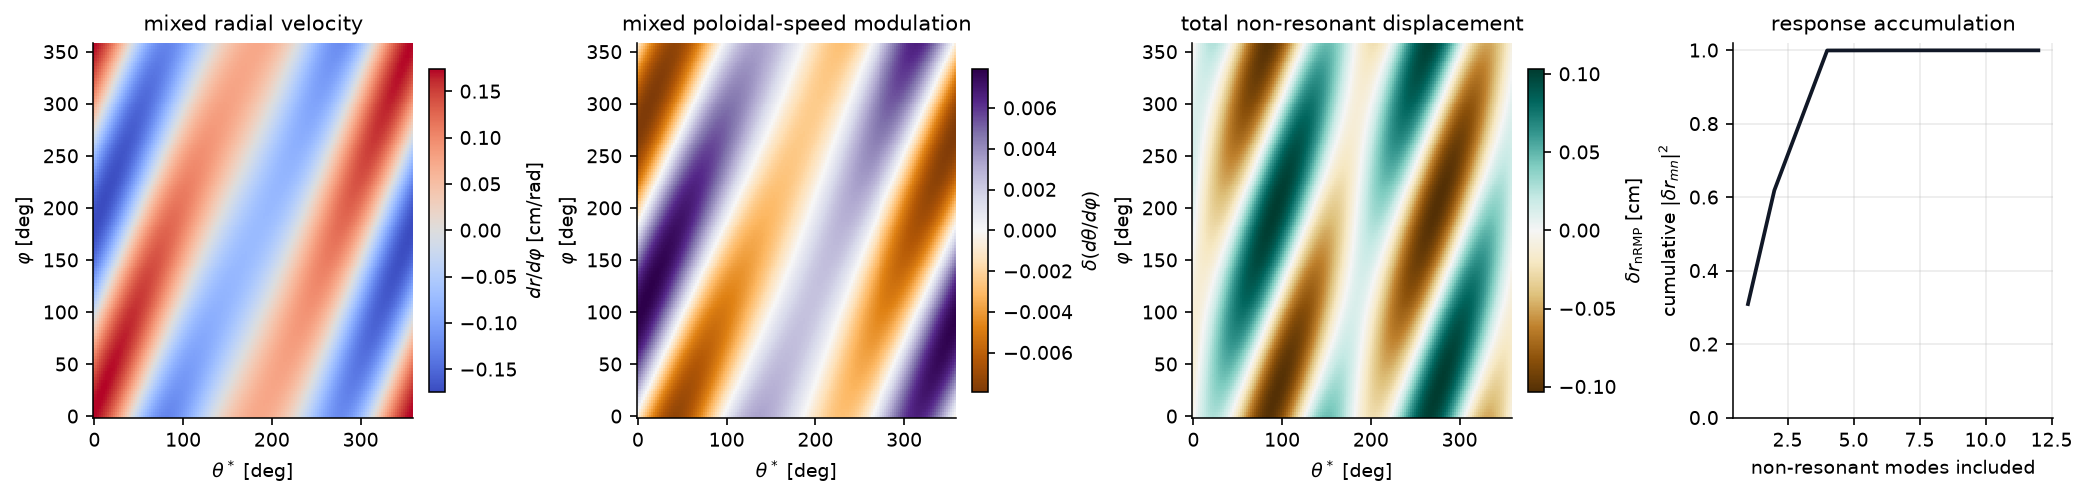

In [10]:
mixed_delta_B = compose_magnetic_perturbations(
    delta_B_RMP,
    radial_rmp_field_template(3, 1, amplitude=2.0e-4, phase=0.20, axis_R=eq.R0),
    radial_rmp_field_template(1, 1, amplitude=1.5e-4, phase=0.40, axis_R=eq.R0),
)

mixed_velocity = fieldline_velocity_spectrum_on_circular_surface(
    eq,
    mixed_delta_B,
    psi_res_21,
    n_theta=160,
    n_phi=128,
    m_max=5,
    n_max=4,
    min_amplitude=1e-13,
)
mixed_rows = rmp_nrmp_mode_rows(
    mixed_velocity.radial_spectrum,
    mixed_velocity.iota,
    resonance_tol=1e-10,
    top=12,
    min_amplitude=1e-8,
)
mixed_response = mixed_velocity.nonresonant_response(include_shear=True, resonance_tol=1e-10)

print(f'Local iota on q=2 surface: {mixed_velocity.iota:.6f}')
print(
    'Total nRMP response uses '
    f'{mixed_response.n_nonresonant_modes} non-resonant modes; '
    f'{mixed_response.n_resonant_modes} resonant modes are left for island analysis.'
)
print()
print('RMP/nRMP mode classification diagnostic:')
print('{:<5} {:>8} {:>12} {:>12} {:>12}'.format('kind', '(m,n)', 'detuning', '|F_r mn|', 'phase [deg]'))
print('-' * 56)
for row in mixed_rows:
    print('{:<5} ({:>2d},{:>2d}) {:>12.3e} {:>12.3e} {:>12.2f}'.format(
        row.kind,
        row.m,
        row.n,
        row.detuning,
        row.amplitude,
        row.phase_deg,
    ))

print()
print('Largest contributors to the total nRMP radial response:')
print('{:>8} {:>12} {:>14} {:>14}'.format('(m,n)', 'detuning', '|delta_r_mn| cm', 'cum frac'))
for contrib in mixed_response.contribution_rows(top=8):
    print('({:>2d},{:>2d}) {:>12.3e} {:>14.4f} {:>14.3f}'.format(
        contrib.m,
        contrib.n,
        contrib.detuning,
        100.0 * contrib.radial_response_weight,
        contrib.cumulative_fraction,
    ))

mixed_deformation = mixed_response.deformation
TT_mix, PP_mix, nonres_dr_mix, nonres_dtheta_mix = mixed_response.real_fields()
counts_mix, cumulative_mix = mixed_response.cumulative_contribution()

theta_deg_mix = np.degrees(mixed_velocity.theta)
phi_deg_mix = np.degrees(mixed_velocity.phi)
fig_mix, axes_mix = plt.subplots(1, 4, figsize=(13.8, 3.2), constrained_layout=True)
panels = [
    (mixed_velocity.radial_velocity * 100.0, r'$dr/d\varphi$ [cm/rad]', 'mixed radial velocity', 'coolwarm'),
    (mixed_velocity.poloidal_velocity, r'$\delta(d\theta/d\varphi)$', 'mixed poloidal-speed modulation', 'PuOr'),
    (nonres_dr_mix * 100.0, r'$\delta r_\mathrm{nRMP}$ [cm]', 'total non-resonant displacement', 'BrBG'),
]
for ax, (data, label, title, cmap) in zip(axes_mix[:3], panels):
    vmax = np.nanmax(np.abs(data))
    im = ax.pcolormesh(
        theta_deg_mix,
        phi_deg_mix,
        data,
        shading='auto',
        cmap=cmap,
        vmin=-vmax,
        vmax=vmax,
    )
    ax.set_xlabel(r'$\theta^*$ [deg]')
    ax.set_ylabel(r'$\varphi$ [deg]')
    ax.set_title(title)
    fig_mix.colorbar(im, ax=ax, label=label, shrink=0.86)
axes_mix[3].plot(counts_mix, cumulative_mix, color='#111827', lw=1.8)
axes_mix[3].set_ylim(0, 1.02)
axes_mix[3].set_xlabel('non-resonant modes included')
axes_mix[3].set_ylabel(r'cumulative $|\delta r_{mn}|^2$')
axes_mix[3].set_title('response accumulation')
axes_mix[3].grid(True, alpha=0.25)
plt.show()


## [ORDER_ANALYSIS] Perturbation-order checks

재사용 가능한 workflow는 이제 몇 개의 작은 helper에 들어 있습니다.
`scan_nonresonant_residual_order`, `scan_rmp_amplitude_order`,
`scan_rmp_phase_order`, `scan_rmp_resolution_convergence`, `plot_perturbation_order_summary`.

Fourier convention이 고정되면 예상 order는 단순합니다.

- nRMP surface-shape residual: first-order deformation은 `O(k^2)` map residual을 남겨야 한다.
- RMP 공명 coefficient: `delta B = k f`이면 Fourier linearity 때문에 `|b_{m,-n}| ~ k`이다.
- 자기섬 폭: Rutherford/Nardon pendulum width는 `w ~ sqrt(|b_{m,-n}|)`로 scaling하므로 `w ~ k^{1/2}`이다.
- X/O phase: phase는 amplitude가 아니라 `arg(b_{m,-n})`에 의해 결정된다. 정확한 관계는 `m*Delta theta_O + Delta arg(b_{m,-n}) = 0`이다.

Phase-control order에는 divergence-free template `radial_rmp_field_template`를 사용합니다. 이 template의 phase parameter는 중요한 `m=1` case까지 포함해 `div(delta B)=0`을 보존하면서 공명 coefficient phase를 바꿉니다. 의도적으로 약한 비선형 control phase `alpha(k)=k+eta*k^2`를 시험하므로, first-order raw-`k` law에 대한 residual은 `O(k^2)`로 scaling해야 합니다.

Non-resonant deformation residual slope = 1.999 (expected 2)
Positive RMP: |b_mn| slope =             1.000 (expected 1)
Positive RMP: island half-width slope =  0.500 (expected 0.5)
Positive RMP: X/O phase span:           0.000e+00 deg
Negative coefficient: arg jump:         180.0 deg
  +k: O=135.0 deg, X=45.0 deg
  -k: O=45.0 deg, X=135.0 deg
Phase template: |Delta arg b| slope =    1.020 (locally expected 1)
Phase template: |Delta theta_O| vs |Delta arg b| slope = 1.000 (expected 1)
Phase template: max |m Delta theta_O + Delta arg b|: 4.441e-16 rad
Phase template: first-order residual slope = 2.000 (expected 2)

Resolution convergence against the finest RMP spectrum grid:
 n_theta  n_phi  rel |b| err  phase err deg  rel width err    max |dr| cm
      32     16    0.000e+00      0.000e+00      0.000e+00         1.2408
      64     32    0.000e+00      0.000e+00      0.000e+00         1.2408
     128     64    0.000e+00      0.000e+00      0.000e+00         1.2408
     256    128    0


Coupled RMP + helical ripple, fixed RMP amplitude:
epsilon_h     raw [cm]  superposed [cm]     nearest [cm]
    0.000       0.2524           0.2524           0.2524
    0.005       0.3280           0.2467           0.2455
    0.010       0.4678           0.2908           0.2883
    0.020       0.8661           0.4838           0.4610
    0.030       1.4484           0.8564           0.7698


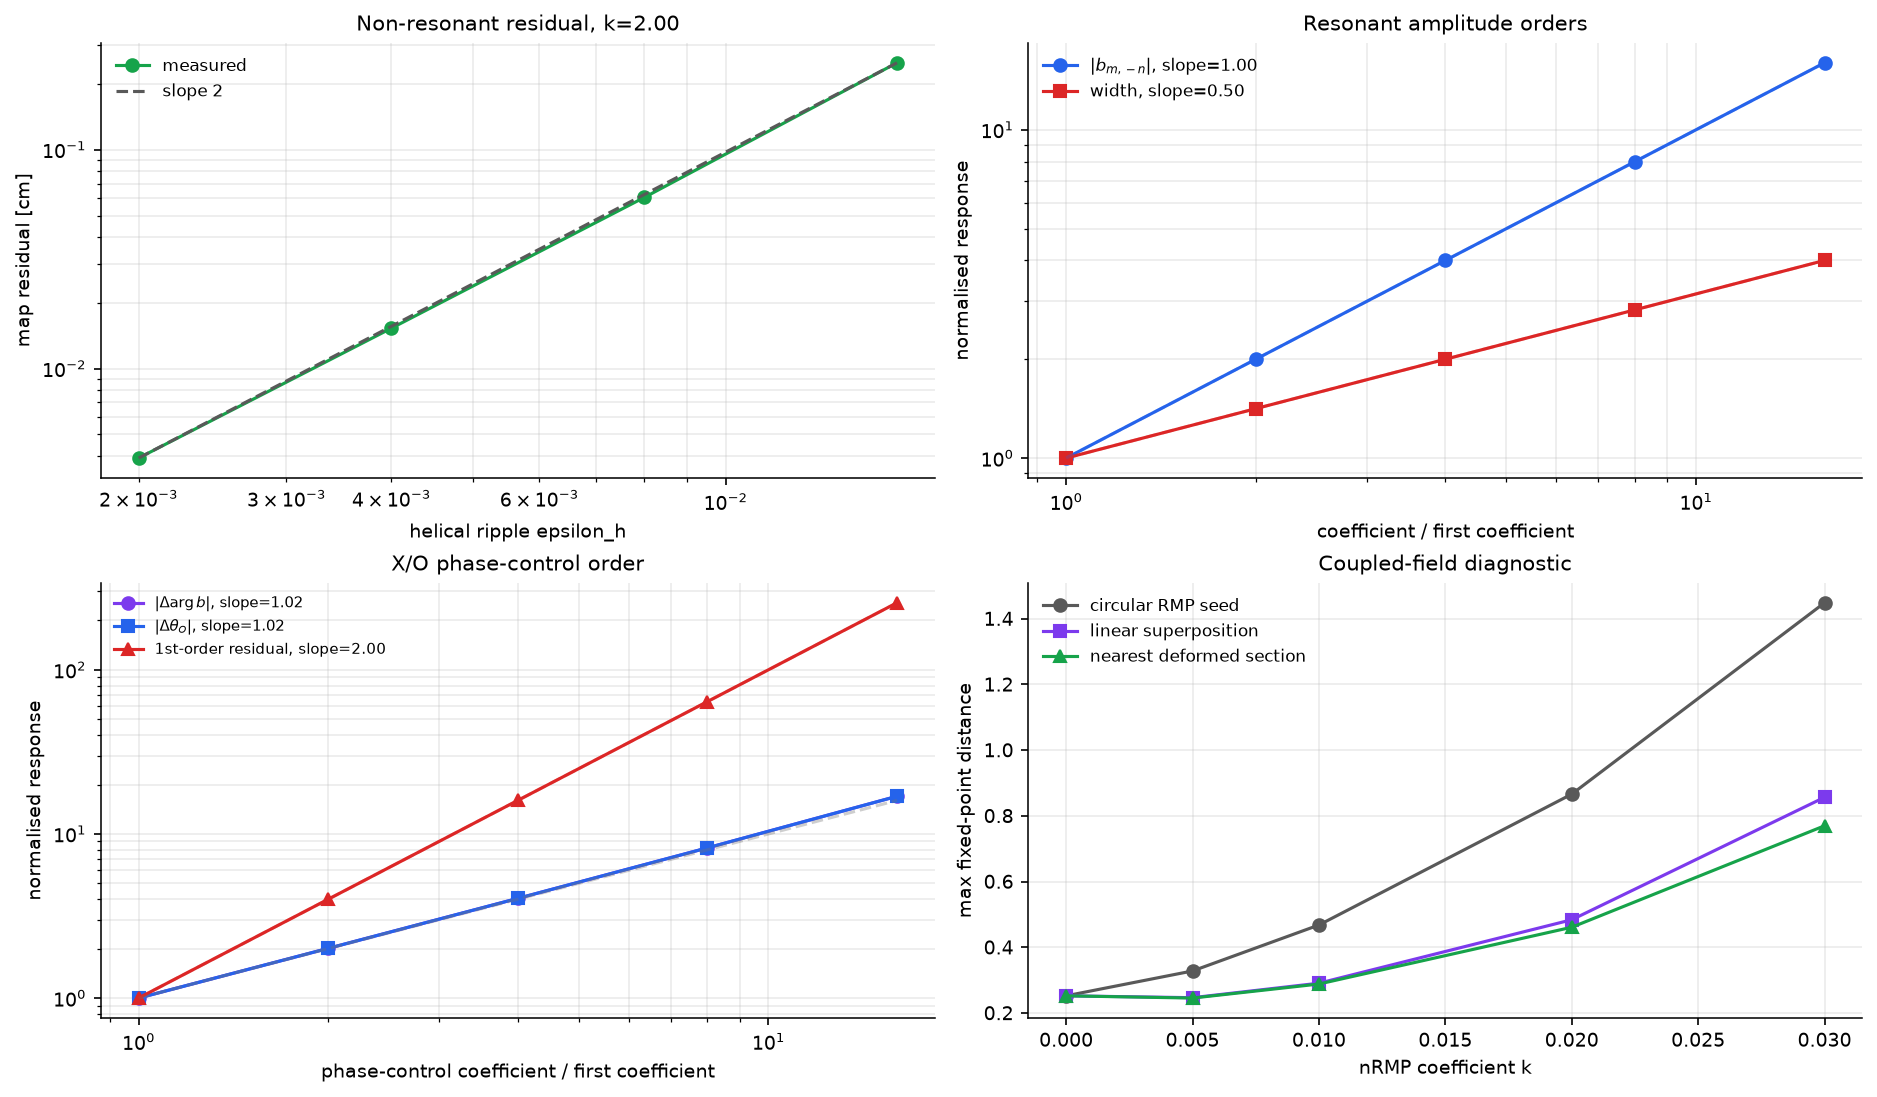

In [11]:
def component_for_rmp_template(amplitude=1.0e-3, phase=0.0, n_theta=128, n_phi=64):
    return find_resonant_components_analytic(
        eq,
        radial_rmp_field_template(base_m, base_n, amplitude=amplitude, phase=phase, axis_R=eq.R0),
        base_m=base_m,
        base_n=base_n,
        max_harmonic=1,
        n_theta=n_theta,
        n_phi=n_phi,
        min_amplitude=1e-16,
        verbose=False,
    )[0]


def deformed_torus_map_residual(epsilon_h, n_alpha=12):
    eq_case = simple_stellarator(
        R0=eq.R0, r0=eq.r0, B0=eq.B0,
        q0=eq.q0, q1=eq.q1,
        m_h=eq.m_h, n_h=eq.n_h, epsilon_h=float(epsilon_h),
    )
    psi_res = eq_case.resonant_psi(base_m, base_n)[0]
    deformation, r_res, _ = helical_velocity_deformation(
        eq_case, psi_res, n_theta=128, n_phi=128, include_shear=True
    )
    iota = 1.0 / float(eq_case.q_of_psi(psi_res))

    def surface(alpha, phi):
        alpha_arr = np.asarray(alpha)
        return (
            r_res + deformation.section_r(alpha_arr, phi),
            alpha_arr + deformation.section_theta(alpha_arr, phi),
        )

    def rhs(phi, state):
        radius, theta = state
        R = eq_case.R0 + radius*np.cos(theta)
        psi_here = (radius / eq_case.r0)**2
        q_here = float(eq_case.q_of_psi(psi_here))
        Bphi = eq_case.B0 * eq_case.R0 / R
        delta_BR = eq_case.epsilon_h * eq_case.B0 * psi_here * np.cos(eq_case.m_h * theta - eq_case.n_h * phi)
        return [
            R * delta_BR * np.cos(theta) / Bphi,
            1.0/q_here - R * delta_BR * np.sin(theta) / (radius * Bphi),
        ]

    residual = deformed_surface_map_residual(
        surface,
        rhs,
        iota,
        alpha_values=np.linspace(0.0, 2*np.pi, n_alpha, endpoint=False),
        state_to_cartesian=lambda state, phi: [
            eq_case.R0 + float(state[0])*np.cos(float(state[1])),
            float(state[0])*np.sin(float(state[1])),
        ],
    )
    return residual.max_residual


def max_helical_deformation_cm(n_theta, n_phi):
    velocity = fieldline_velocity_spectrum_on_circular_surface(
        eq,
        helical_ripple_delta_B(eq),
        psi_res_21,
        n_theta=max(64, n_theta),
        n_phi=max(64, n_phi),
        m_max=8,
        n_max=8,
        min_amplitude=1e-12,
    )
    deformation = velocity.nonresonant_deformation(include_shear=True)
    TT, PP = np.meshgrid(velocity.theta, velocity.phi, indexing='xy')
    return 100.0 * float(np.nanmax(np.abs(deformation.real_field_r(TT, PP))))


nonres_eps = np.array([0.002, 0.004, 0.008, 0.016])
rmp_k = np.array([2.5e-4, 5e-4, 1e-3, 2e-3, 4e-3])
phase_controls = np.array([0.01, 0.02, 0.04, 0.08, 0.16])
phase_eta = 0.4

nonres_scan = scan_nonresonant_residual_order(nonres_eps, deformed_torus_map_residual)
rmp_amp_scan = scan_rmp_amplitude_order(
    rmp_k,
    lambda k: component_for_rmp_template(amplitude=k, phase=0.0, n_theta=64, n_phi=32),
)
phase_base = component_for_rmp_template(amplitude=1e-3, phase=0.0, n_theta=128, n_phi=64)
phase_scan = scan_rmp_phase_order(
    phase_controls,
    lambda k: component_for_rmp_template(
        amplitude=1e-3,
        phase=float(k) + phase_eta*float(k)*float(k),
        n_theta=128,
        n_phi=64,
    ),
    base_component=phase_base,
)
resolution_scan = scan_rmp_resolution_convergence(
    [(32, 16), (64, 32), (128, 64), (256, 128)],
    lambda n_theta, n_phi: component_for_rmp_template(
        amplitude=1e-3, phase=0.0, n_theta=n_theta, n_phi=n_phi
    ),
    deformation_metric_factory=max_helical_deformation_cm,
)

comp_pos = component_for_rmp_template(amplitude=1e-3, phase=0.0, n_theta=64, n_phi=32)
comp_neg = component_for_rmp_template(amplitude=-1e-3, phase=0.0, n_theta=64, n_phi=32)
sign_phase_jump_deg = float(np.degrees(np.angle(comp_neg.b_mn / comp_pos.b_mn)))

print(f'Non-resonant deformation residual slope = {nonres_scan.slope:.3f} (expected 2)')
print(f'Positive RMP: |b_mn| slope =             {rmp_amp_scan.b_fit.slope:.3f} (expected 1)')
print(f'Positive RMP: island half-width slope =  {rmp_amp_scan.width_fit.slope:.3f} (expected 0.5)')
print(f'Positive RMP: X/O phase span:           {rmp_amp_scan.phase_span_deg:.3e} deg')
print(f'Negative coefficient: arg jump:         {sign_phase_jump_deg:.1f} deg')
print(f'  +k: O={np.degrees(comp_pos.opoint_theta):.1f} deg, X={np.degrees(comp_pos.xpoint_theta):.1f} deg')
print(f'  -k: O={np.degrees(comp_neg.opoint_theta):.1f} deg, X={np.degrees(comp_neg.xpoint_theta):.1f} deg')
print(f'Phase template: |Delta arg b| slope =    {phase_scan.b_phase_fit.slope:.3f} (locally expected 1)')
print(f'Phase template: |Delta theta_O| vs |Delta arg b| slope = {phase_scan.opoint_vs_b_phase_fit.slope:.3f} (expected 1)')
print(f'Phase template: max |m Delta theta_O + Delta arg b|: {phase_scan.max_exact_relation_residual:.3e} rad')
print(f'Phase template: first-order residual slope = {phase_scan.first_order_residual_fit.slope:.3f} (expected 2)')

print()
print('Resolution convergence against the finest RMP spectrum grid:')
print('{:>8} {:>6} {:>12} {:>14} {:>14} {:>14}'.format(
    'n_theta', 'n_phi', 'rel |b| err', 'phase err deg', 'rel width err', 'max |dr| cm'
))
for row in resolution_scan.rows:
    print(f'{row.n_theta:8d} {row.n_phi:6d} {row.relative_b_error:12.3e} '
          f'{row.phase_error_deg:14.3e} {row.relative_width_error:14.3e} '
          f'{row.deformation_metric:14.4f}')

coupling_sweep = None
if components:
    component = components[0]

    def coupled_distances(eps_h):
        eq_case = simple_stellarator(
            R0=eq.R0, r0=eq.r0, B0=eq.B0,
            q0=eq.q0, q1=eq.q1,
            m_h=eq.m_h, n_h=eq.n_h, epsilon_h=float(eps_h),
        )
        rows = compare_cyna_fixed_points_for_component(
            sample_stellarator_cylindrical_field(
                eq_case, delta_B_RMP, nR=128, nPhi=128, label=f'coupled_rmp_eps_{eps_h:.3f}',
            ),
            component,
            eq_case,
            DPhi=0.015,
            max_iter=80,
            tol=1e-11,
            n_threads=4,
        )
        raw_cm = max(np.hypot(row.newton_R - row.predicted_R, row.newton_Z - row.predicted_Z) for row in rows) * 100.0
        if eps_h == 0.0:
            return raw_cm, raw_cm, raw_cm
        deformation, r_res, _ = helical_velocity_deformation(eq_case, component.psi_res, include_shear=True)
        superposed_cm = max(
            np.hypot(
                float(deformed_circular_section_rz(eq_case, r_res, deformation, row.predicted_theta)[0]) - row.newton_R,
                float(deformed_circular_section_rz(eq_case, r_res, deformation, row.predicted_theta)[1]) - row.newton_Z,
            ) for row in rows
        ) * 100.0
        projected = project_fixed_points_to_deformed_surface(rows, eq_case, deformation, r_minor=r_res)
        return raw_cm, superposed_cm, max(row.distance_cm for row in projected)

    try:
        coupling_sweep = scan_coupled_fixed_point_sweep(np.array([0.0, 0.005, 0.01, 0.02, 0.03]), coupled_distances)
    except ImportError as exc:
        print('Coupled cyna sweep skipped:', exc)

if coupling_sweep is not None:
    print()
    print('Coupled RMP + helical ripple, fixed RMP amplitude:')
    print('{:>9} {:>12} {:>16} {:>16}'.format('epsilon_h', 'raw [cm]', 'superposed [cm]', 'nearest [cm]'))
    for eps_h, raw_cm, superposed_cm, nearest_cm in zip(
        coupling_sweep.k, coupling_sweep.raw_distance,
        coupling_sweep.superposed_distance, coupling_sweep.nearest_deformed_distance,
    ):
        print(f'{eps_h:9.3f} {raw_cm:12.4f} {superposed_cm:16.4f} {nearest_cm:16.4f}')

fig_order, axes_order = plot_perturbation_order_summary(
    nonresonant=nonres_scan,
    rmp_amplitude=rmp_amp_scan,
    rmp_phase=phase_scan,
    coupling=coupling_sweep,
    residual_scale=100.0,
    residual_label='map residual [cm]',
    coefficient_label='helical ripple epsilon_h',
)
plt.show()


## [ISLAND_WIDTHS] 자기섬 폭 bar chart와 Chirikov overlap diagram

**Chirikov overlap parameter**는
$$\sigma=\frac{w_1+w_2}{|r_1-r_2|}$$
로 정의됩니다. 여기서 $w_i$는 half-width이고 $r_i$는 인접 자기섬의 radial position입니다. $\sigma\gtrsim1$일 때 stochastic transport가 시작됩니다.

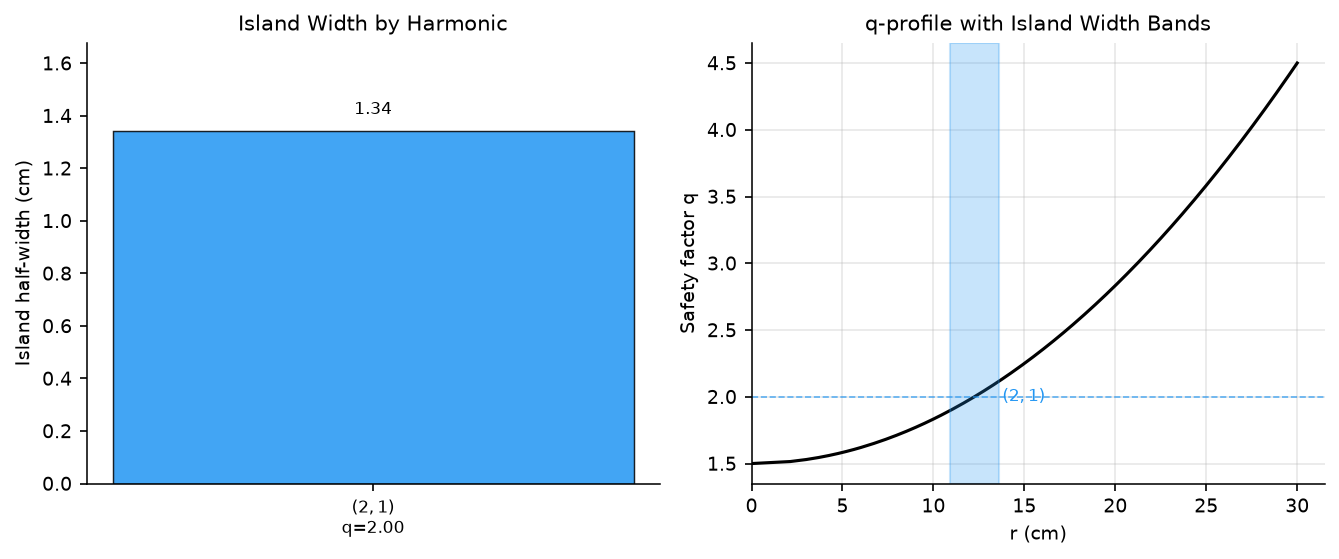

In [12]:
fig_iw, (ax_bar, ax_q) = plt.subplots(1, 2, figsize=(9, 3.8))

# ── (a) Island width bar chart ───────────────────────────────────────────
labels = [f'$({c.m},{c.n})$\nq={c.q_res:.2f}' for c in components]
widths_cm = [c.half_width_r * 100 for c in components]
colors_bar = [ISLAND_CMAPS[(c.harmonic_order - 1) % len(ISLAND_CMAPS)] for c in components]

x_pos = np.arange(len(components))
bars = ax_bar.bar(x_pos, widths_cm, color=colors_bar, edgecolor='k',
                  linewidth=0.7, alpha=0.85, width=0.55)
for bar, w in zip(bars, widths_cm):
    ax_bar.text(bar.get_x() + bar.get_width()/2, w + 0.05,
                f'{w:.2f}', ha='center', va='bottom', fontsize=8)

ax_bar.set_xticks(x_pos)
ax_bar.set_xticklabels(labels, fontsize=8)
ax_bar.set_ylabel('Island half-width (cm)')
ax_bar.set_title('Island Width by Harmonic')
ax_bar.set_ylim(0, max(widths_cm)*1.25 if widths_cm else 1)

# ── (b) q-profile with island width bands ───────────────────────────────
psi_arr = np.linspace(0, 1, 200)
r_arr = np.sqrt(psi_arr) * eq.r0
q_arr = eq.q_of_psi(psi_arr)

ax_q.plot(r_arr * 100, q_arr, 'k-', linewidth=1.5, label='q(r)')
ax_q.set_xlabel('r (cm)')
ax_q.set_ylabel('Safety factor q')
ax_q.set_title('q-profile with Island Width Bands')

# Draw horizontal bands for each resonance
chirikov_pairs = []
for c in components:
    color = ISLAND_CMAPS[(c.harmonic_order - 1) % len(ISLAND_CMAPS)]
    r_res = np.sqrt(c.psi_res) * eq.r0 * 100  # cm
    w_r = c.half_width_r * 100  # cm
    q_res = c.q_res
    # Island band in r
    ax_q.axvspan(r_res - w_r, r_res + w_r, alpha=0.25, color=color, zorder=2)
    ax_q.axhline(q_res, color=color, lw=0.8, linestyle='--', alpha=0.7)
    ax_q.text(r_res + w_r + 0.2, q_res, f'$({c.m},{c.n})$',
              color=color, fontsize=8, va='center')
    chirikov_pairs.append((r_res, w_r))

# Chirikov overlap
if len(chirikov_pairs) >= 2:
    for i in range(len(chirikov_pairs) - 1):
        r1, w1 = chirikov_pairs[i]
        r2, w2 = chirikov_pairs[i+1]
        gap = abs(r2 - r1)
        sigma = (w1 + w2) / gap if gap > 0 else float('inf')
        print(f'Chirikov sigma between ({components[i].m},{components[i].n}) and ({components[i+1].m},{components[i+1].n}): {sigma:.3f}')

ax_q.set_xlim(0, eq.r0 * 100 * 1.05)
ax_q.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## [MN_SPECTRUM] 2-D Fourier 스펙트럼 heatmap

Primary 공명 surface에서 divergence-free RMP template의 전체 $(m,n)$ Fourier 스펙트럼을 계산합니다. 공명 mode $(2,-1)$와 그 driven harmonic을 강조합니다. 위 mixed-spectrum section은 detuning에 따라 공명 row와 비공명 row를 분류하는 companion view입니다.

Computing (m,n) spectrum on q=2 surface (psi=0.167), n_theta=48, n_phi=48...
Spectrum shape: (13, 9)


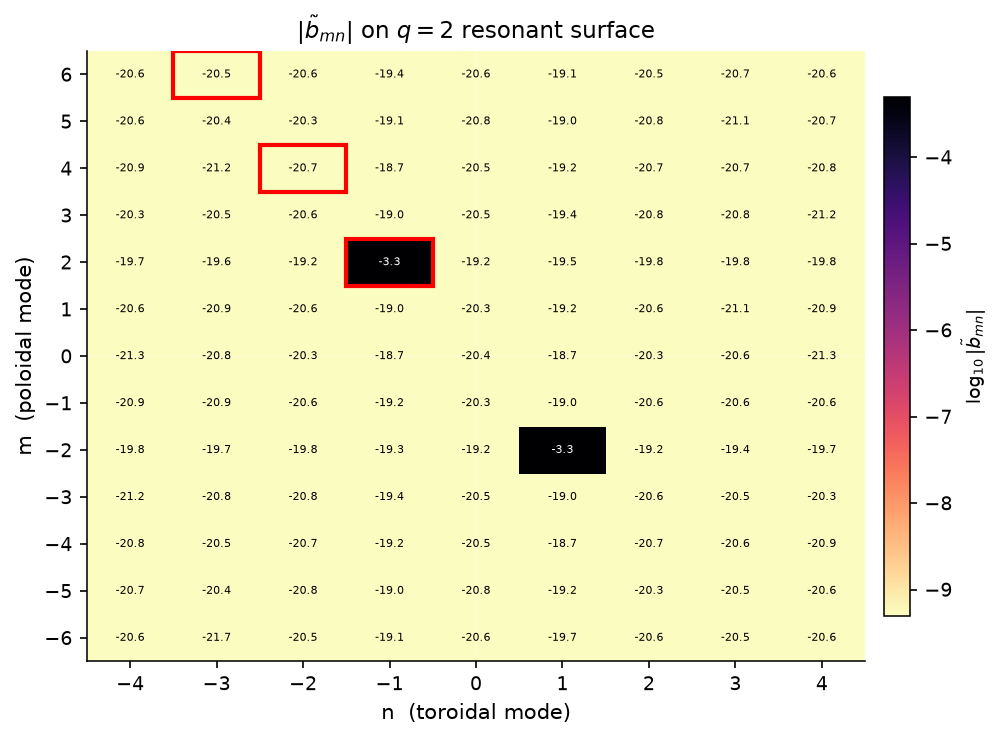

In [13]:
psi_res_21 = eq.resonant_psi(2, 1)[0]
print(f'Computing (m,n) spectrum on q=2 surface (psi={psi_res_21:.3f}), n_theta=48, n_phi=48...')
b_mn = compute_mn_spectrum(
    delta_B_RMP,
    S=psi_res_21,
    equilibrium=eq,
    m_max=6,
    n_max=4,
    n_theta=48,
    n_phi=48,
)
print(f'Spectrum shape: {b_mn.shape}')

fig_sp, ax_sp = plt.subplots(figsize=(7, 5))
plot_mn_heatmap(
    b_mn, m_max=6, n_max=4,
    ax=ax_sp,
    log_scale=True,
    title=r'$|\tilde{b}_{mn}|$ on $q=2$ resonant surface',
    cmap='magma_r',
    highlight_modes=[(2, -1), (4, -2), (6, -3)],
)
plt.tight_layout()
plt.show()

## [MAGNETIC_SPECTRUM_ATLAS] Multi-component 반변 $B^r$ 스펙트럼 atlas

위 single-surface heatmap은 dominant RMP row를 확인하는 데 유용하지만, 실제 자기 위상 분석에는 보통 family view가 필요합니다. 여기서는 divergence-free multi-component perturbation을 만들고, radial stack 위에서 Nardon-style 반변 radial 스펙트럼 $\tilde b^1_{mn}=\delta B^1/B_0^3$를 계산한 뒤 요청한 모든 공명 row를 함께 분석합니다.

아래 utility는 의도적으로 modular합니다. 표시된 atlas는 더 넓은 signed Fourier window, 97개의 radial surface, `amplitude_scale='sqrt'`, zero/missing row에 대한 white mask를 사용합니다. Non-log colormap은 같은 white baseline에서 시작하므로 near-zero coefficient가 masked background와 인위적으로 분리되어 보이지 않습니다. Signed axis는 계산된 스펙트럼의 실제 Fourier row를 보여 줍니다. 실수 field에서는 `(m,n)`이 `(-m,-n)`과 conjugate이지만, perturbation model이 추가 symmetry를 강제하지 않는 한 `(m,n)`과 `(m,-n)`은 서로 독립인 opposite-helicity row입니다. `amplitude_scale='log10'`은 엄격한 dynamic-range auditing이 목적일 때 여전히 유용합니다.

- `plot_rational_surface_map`은 optional q 프로파일, low-order rational marker, projected Poincaré point, 자기섬 폭 bar를 `(m/n,s)` plane에서 조합합니다.
- `plot_spectrum_heatmap(..., renderer='pcolormesh')`는 권장 surface-spectrum view입니다. Opposite-helicity branch를 그리지 않고 physical 공명 branch `m=-q n_F`를 overlay할 수 있습니다.
- `plot_spectrum_bar3d`는 dominant row의 rotation, zoom, hover inspection을 위한 interactive Plotly figure를 반환합니다.
- `plot_radial_mode_heatmap(fixed_n=..., resonant_sign=+1)`은 fixed Fourier $n$에서 모든 $m$ row를 따라가며, positive-q branch $m=-nq(s)$를 negative-$m$ half-plane에 그립니다.
- `plot_radial_mode_heatmap(fixed_m=..., axis_convention='fourier')`는 실제 Fourier $n$ row를 따라가고 positive-q branch $n=-m/q(s)$를 그립니다. q-curve와 자기섬 폭 bar는 독립적으로 켜고 끌 수 있습니다.

노란 vertical bar는 low-order rational surface에서 single-coefficient Nardon half-width estimate를 표시합니다. 두께는 공명 coefficient amplitude와 함께 scaling합니다. 이것은 optional overlay이며 heatmap 자체의 일부가 아닙니다. 각 radial map에는 물리적으로 공명하는 curve만 그립니다. Opposite-helicity branch는 conjugate diagnostic이 아니므로 여기서는 mirror하지 않습니다. 같은 reduced rational surface를 여러 harmonic이 공유하는 경우, 진짜 finite-amplitude 자기섬 폭은 combined resonant Hamiltonian으로 계산해야 합니다. Per-row bar는 diagnostic이지 그 nonlinear summed width가 아닙니다.

Radial spectrum: 97 surfaces, 22 retained Fourier rows over |m|<=14, |n|<=8.
Multi-RMP analysis found 7 resonant island-chain estimates.
  (m,n)     s_res     q_res        b_res   half_width      phase
( 2,1)    0.1667    2.0000    1.661e-03    6.655e-02       0.6°
( 3,1)    0.5000    3.0000    1.535e-03    7.836e-02      27.6°
( 5,2)    0.3333    2.5000    7.401e-04    3.512e-02     -20.1°
( 4,1)    0.8333    4.0000    1.665e-04    2.980e-02      30.1°
( 6,2)    0.5000    3.0000    6.400e-05    1.131e-02     -20.1°
( 4,2)    0.1667    2.0000    2.132e-05    5.332e-03     -20.1°
( 7,2)    0.6667    3.5000    1.742e-06    2.016e-03     -20.1°


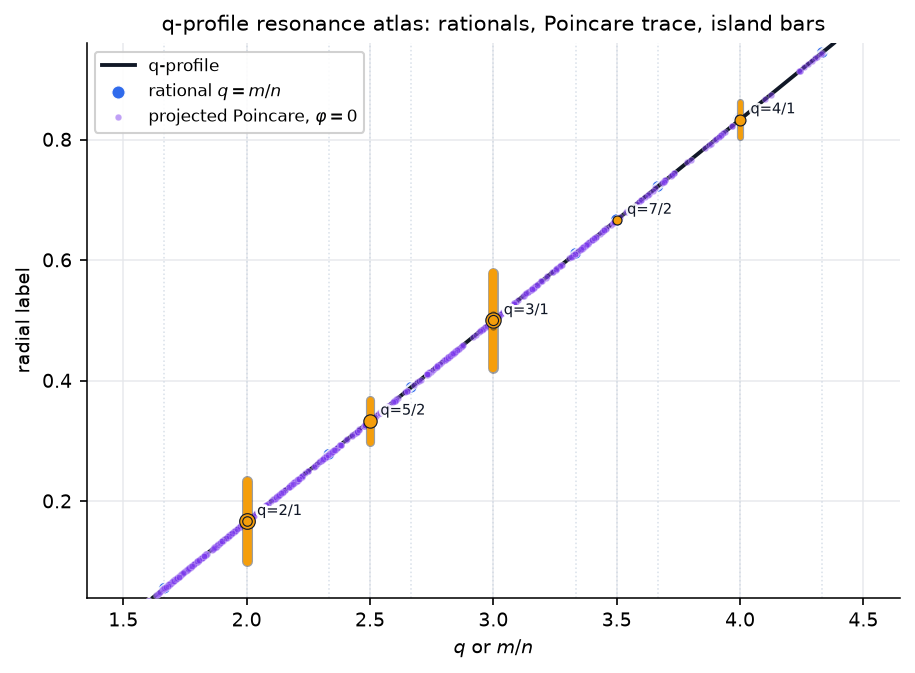

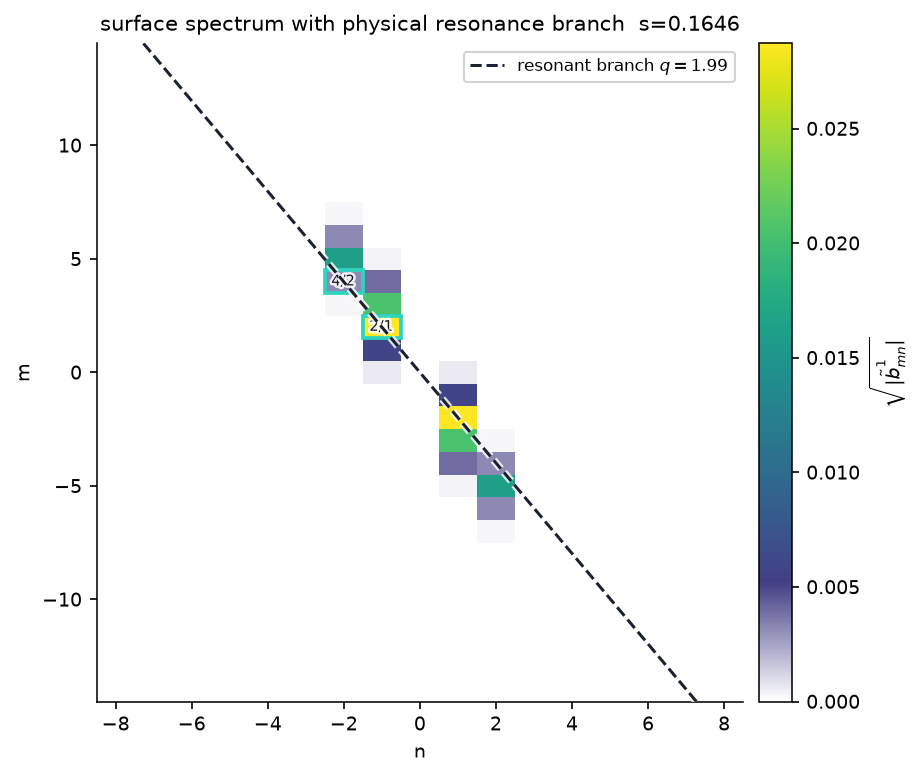

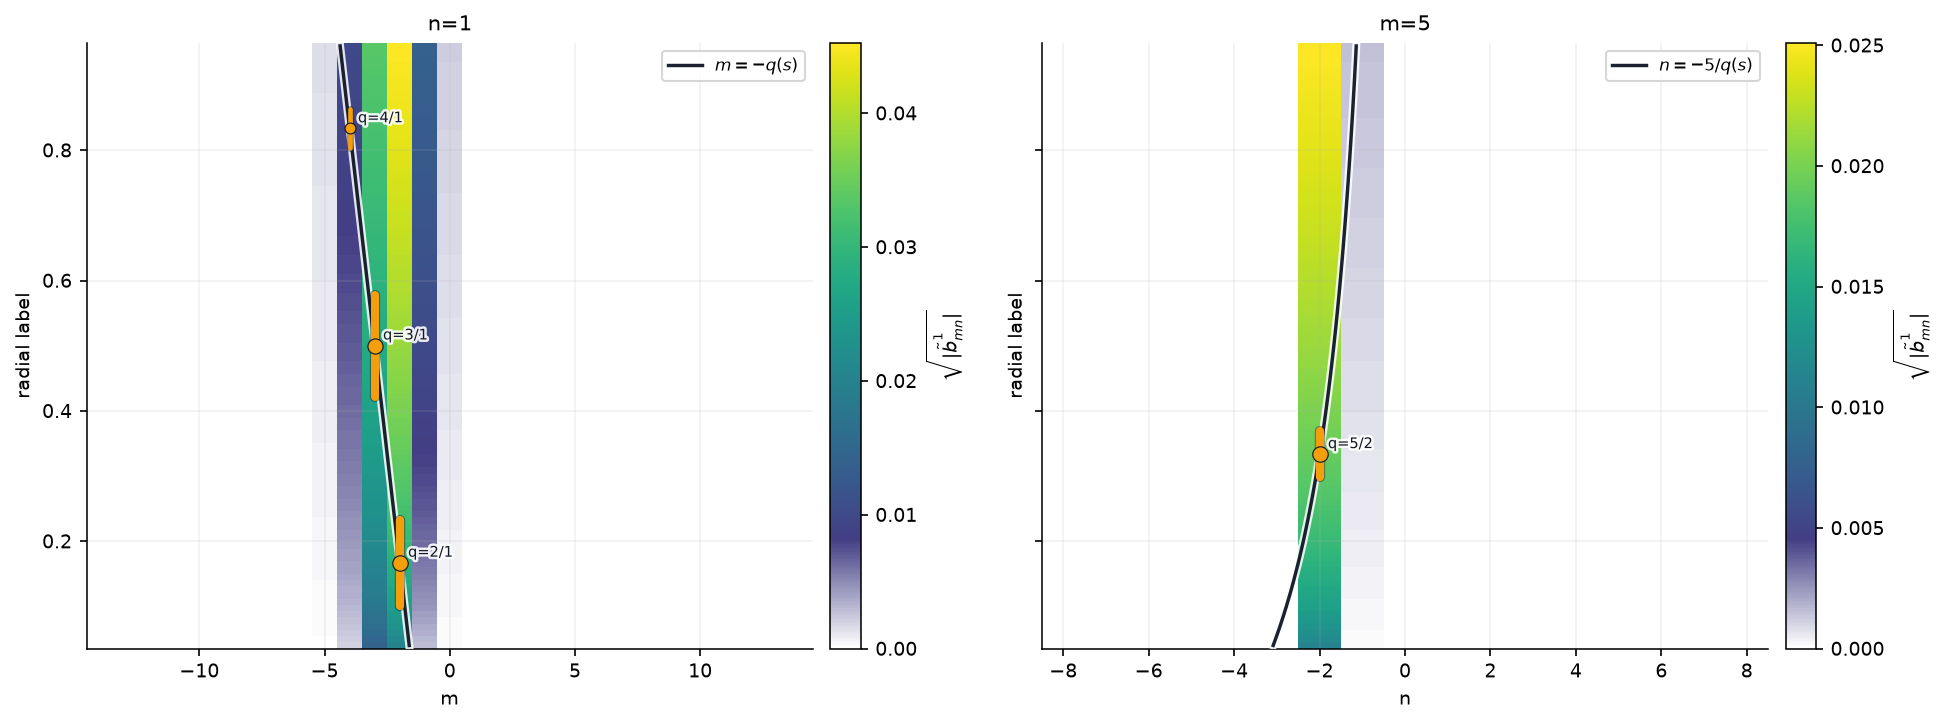

In [14]:
delta_B_multi_rmp = compose_magnetic_perturbations(
    radial_rmp_field_template(2, 1, amplitude=5.0e-4, phase=0.00, axis_R=eq.R0),
    radial_rmp_field_template(3, 1, amplitude=2.4e-4, phase=0.55, axis_R=eq.R0),
    radial_rmp_field_template(5, 2, amplitude=1.6e-4, phase=-0.35, axis_R=eq.R0),
)

S_scan = np.linspace(0.04, 0.96, 97)
theta_spec = np.linspace(0.0, 2*np.pi, 160, endpoint=False)
phi_spec = np.linspace(0.0, 2*np.pi, 96, endpoint=False)

theta_grid = theta_spec[None, None, :]
phi_grid = phi_spec[:, None, None]
r_scan = eq.r0 * np.sqrt(S_scan)[None, :, None]
R_stack = eq.R0 + r_scan * np.cos(theta_grid)
Z_stack = r_scan * np.sin(theta_grid)
R_stack = np.repeat(R_stack, phi_spec.size, axis=0)
Z_stack = np.repeat(Z_stack, phi_spec.size, axis=0)
Phi_stack = phi_grid + np.zeros_like(R_stack)

dBR_stack, dBZ_stack, dBphi_stack = delta_B_multi_rmp(R_stack, Z_stack, Phi_stack)
Bphi0_stack = eq.B0 * eq.R0 / np.maximum(R_stack, 1.0e-12)
tilde_b1_grid = nardon_radial_perturbation(
    R_stack,
    Z_stack,
    phi_spec,
    theta_spec,
    dBR_stack,
    dBZ_stack,
    dBphi_stack,
    S_scan,
    denominator_B_phi=Bphi0_stack,
)
magnetic_spectrum = radial_perturbation_Fourier_spectrum(
    tilde_b1_grid,
    theta_spec,
    phi_spec,
    radial_labels=S_scan,
    m_max=14,
    n_max=8,
    min_amplitude=1.0e-14,
)
q_scan = eq.q_of_psi(S_scan)
n_scan = [1, 2, 3]
m_scan = {1: range(1, 9), 2: range(2, 13), 3: range(3, 15)}
chains_multi = analyze_resonant_island_chains_multi_n(
    magnetic_spectrum,
    q_scan,
    n_values=n_scan,
    m_values=m_scan,
    min_b_res=1.0e-8,
)

print(f'Radial spectrum: {S_scan.size} surfaces, {magnetic_spectrum.m.size} retained Fourier rows over |m|<=14, |n|<=8.')
print(f'Multi-RMP analysis found {len(chains_multi)} resonant island-chain estimates.')
print('{:>7} {:>9} {:>9} {:>12} {:>12} {:>10}'.format('(m,n)', 's_res', 'q_res', 'b_res', 'half_width', 'phase'))
for chain in sorted(chains_multi, key=lambda item: item.b_res, reverse=True)[:8]:
    print('({:>2d},{:>1d}) {:>9.4f} {:>9.4f} {:>12.3e} {:>12.3e} {:>9.1f}°'.format(
        chain.m, chain.n, chain.radial_label, chain.q, chain.b_res, chain.half_width, np.degrees(chain.phase)
    ))

review_root = PROJECT_ROOT if PROJECT_ROOT is not None else pathlib.Path.cwd()
review_dir = review_root / 'pyna_output/magnetic_spectrum_review'
review_dir.mkdir(parents=True, exist_ok=True)

poincare_trace = None
if 'R_cross_p0' in globals() and len(R_cross_p0):
    S_p0 = np.clip(((R_cross_p0 - eq.R0)**2 + Z_cross_p0**2) / eq.r0**2, 0.0, 1.0)
    q_p0 = eq.q_of_psi(S_p0)
    poincare_trace = PoincareRationalTrace(
        ratio=q_p0,
        radial_label=S_p0,
        label=r'projected Poincare, $\varphi=0$',
    )

fig_qmap, ax_qmap, rational_markers = plot_rational_surface_map(
    S_scan,
    q_scan,
    n_values=n_scan,
    m_values=m_scan,
    chains=chains_multi,
    poincare=poincare_trace,
    show_poincare=poincare_trace is not None,
    max_island_bars=12,
    annotate_rationals=False,
    title='q-profile resonance atlas: rationals, Poincare trace, island bars',
)
fig_qmap.savefig(review_dir / '01_q_profile_resonance_map.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

surface_index = int(np.argmin(np.abs(S_scan - psi_res_21)))
surface_label = float(S_scan[surface_index])
chains_surface = [chain for chain in chains_multi if abs(chain.radial_label - surface_label) <= 0.08]
fig_surface, ax_surface = plt.subplots(figsize=(6.7, 5.7))
plot_spectrum_heatmap(
    magnetic_spectrum,
    radial_index=surface_index,
    m_values=np.arange(-14, 15),
    n_values=np.arange(-8, 9),
    chains=chains_surface,
    q_value=float(q_scan[surface_index]),
    renderer='pcolormesh',
    amplitude_scale='sqrt',
    mask_zeros=True,
    ax=ax_surface,
    cmap='viridis',
    title='surface spectrum with physical resonance branch',
)
fig_surface.savefig(review_dir / '02_surface_pcolormesh_atlas.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

fig_bar3d = plot_spectrum_bar3d(
    magnetic_spectrum,
    radial_index=surface_index,
    m_values=np.arange(-10, 11),
    n_values=np.arange(-6, 7),
    amplitude_scale='sqrt',
    range_mode='nonzero',
    bar_width=0.9,
    z_aspect=0.72,
    title='interactive 3D spectrum bars',
)
fig_bar3d.write_html(str(review_dir / '04_surface_plotly_bar3d.html'), include_plotlyjs='cdn')
try:
    fig_bar3d.write_image(str(review_dir / '04_surface_plotly_bar3d.png'), width=1040, height=650, scale=2)
except Exception as exc:
    print(f'Plotly static PNG export skipped: {exc}')
fig_bar3d.show()

fig_radial, axes_radial = plt.subplots(1, 2, figsize=(13.2, 4.9), sharey=True)
plot_radial_mode_heatmap(
    magnetic_spectrum,
    fixed_n=1,
    mode_values=np.arange(-14, 15),
    resonant_sign=1,
    q_profile=q_scan,
    chains=chains_multi,
    renderer='pcolormesh',
    amplitude_scale='sqrt',
    mask_zeros=True,
    ax=axes_radial[0],
    cmap='viridis',
    title='n=1',
)
plot_radial_mode_heatmap(
    magnetic_spectrum,
    fixed_m=5,
    mode_values=np.arange(-8, 9),
    axis_convention='fourier',
    q_profile=q_scan,
    chains=chains_multi,
    renderer='pcolormesh',
    amplitude_scale='sqrt',
    mask_zeros=True,
    ax=axes_radial[1],
    cmap='viridis',
    title='m=5',
)
plt.tight_layout()
fig_radial.savefig(review_dir / '03_radial_fixed_n_fixed_m_maps.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()


## [PUBLICATION_FIGURE] Multi-phi 6-panel figure

같은 section helper는 compact multi-section layout으로도 확장됩니다. O/X marker, O-point 자기섬 폭 bar, local stable branch는 toroidal angle과 함께 회전하고, PEST-style grid는 모든 panel에서 coordinate meaning을 보이게 유지합니다.

Saved publication figure to pyna_output/rmp_resonance_publication.png


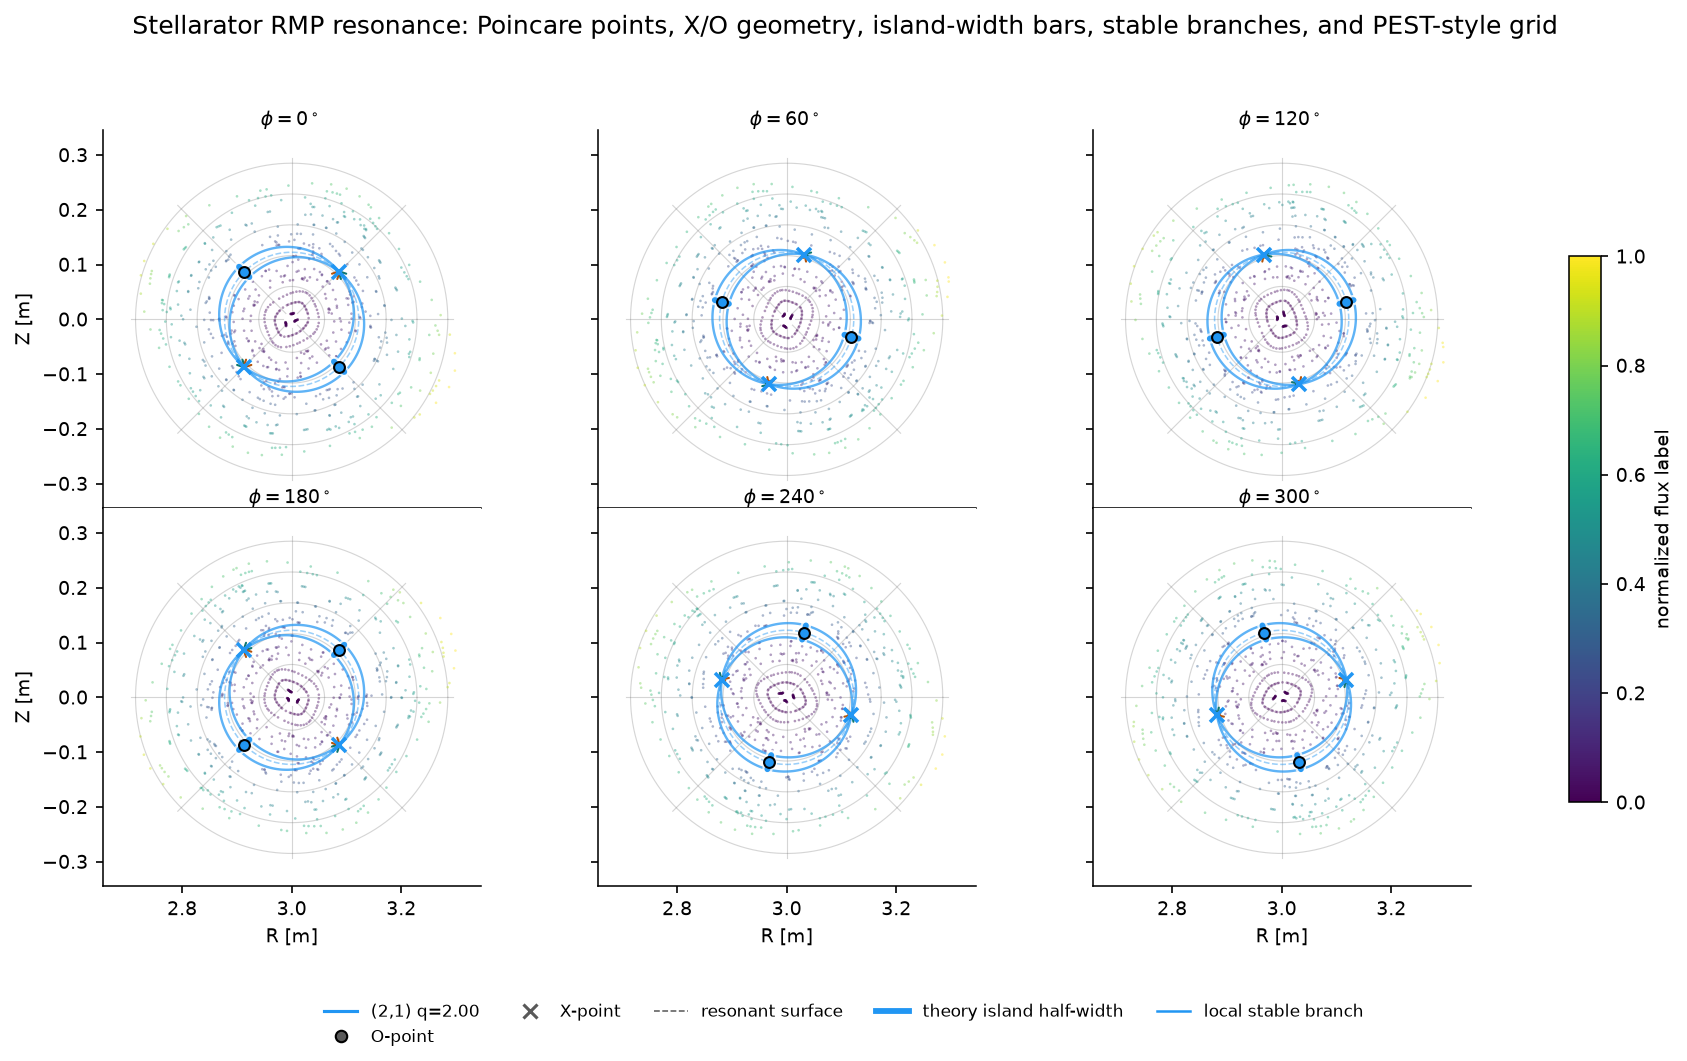

In [15]:
fig_pub, axes_pub = plot_rmp_resonance_sections(
    all_sections_data,
    phi_sections,
    eq=eq,
    components=components,
    colors=ISLAND_CMAPS,
    ncols=3,
    figsize=(12.0, 7.0),
    point_size=1.6,
    point_alpha=0.42,
    compact=True,
    overlays=('pest_grid', 'poincare', 'resonant_surfaces', 'stable_branches', 'island_width_bars', 'xo'),
    title=(
        'Stellarator RMP resonance: Poincare points, X/O geometry, '
        'island-width bars, stable branches, and PEST-style grid'
    ),
)

out_path = pathlib.Path('pyna_output/rmp_resonance_publication.png')
out_path.parent.mkdir(exist_ok=True)
fig_pub.savefig(str(out_path), dpi=170, bbox_inches='tight', facecolor='white')
print(f'Saved publication figure to {out_path}')
from IPython.display import display
display(fig_pub)
plt.close(fig_pub)
